# Construcción de variables de comportamiento de consumo para segmentación de hogares

## Contexto del proyecto

El proyecto final solicita desarrollar una solución de Machine Learning orientada a la toma de decisiones, con preparación de datos, análisis exploratorio, selección de variables, modelado posterior, evaluación e interpretación ejecutiva. Bajo ese enfoque, esta libreta documenta la etapa previa al modelado: construcción y validación de una matriz de comportamiento de consumo para hogares con medidores inteligentes.

La pregunta de negocio que guía esta libreta es:

**¿Qué patrones de consumo permiten identificar hogares con potencial para campañas, promociones o recomendaciones energéticas personalizadas?**

## Objetivo de la libreta

Construir un DataFrame final, denominado `DF_Comportamiento_cluster`, con variables numéricas interpretables y viables para una etapa posterior de clustering. La libreta no entrena modelos; se concentra en justificar la selección de variables mediante calidad de datos, correlaciones, outliers, comportamiento horario y utilidad de negocio.

## Criterios de selección

Las variables seleccionadas deben cumplir cuatro criterios:

1. Tener interpretación de negocio clara.
2. Representar comportamiento de consumo, no solo tamaño del hogar.
3. Evitar redundancia excesiva entre variables.
4. Estar listas para una etapa posterior de modelado no supervisado.


# 1. Configuración y rutas

Esta sección define rutas y genera un DataFrame con la disponibilidad de archivos clave.

In [ ]:
from pathlib import Path
import os
import warnings

os.environ.setdefault("MPLCONFIGDIR", str((Path("./.matplotlib_cache")).resolve()))
os.environ.setdefault("XDG_CACHE_HOME", str((Path("./.cache")).resolve()))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
from IPython.display import display


warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

PROJECT_DIR = Path.cwd()
ORIGINAL_BASE = PROJECT_DIR / "data" / "original" / "kagglehub" / "datasets" / "jeanmidev" / "smart-meters-in-london" / "versions" / "21"
DAILY_PATH = ORIGINAL_BASE / "daily_dataset.csv"
HOUSEHOLDS_PATH = ORIGINAL_BASE / "informations_households.csv"
HHBLOCK_DIR = ORIGINAL_BASE / "hhblock_dataset" / "hhblock_dataset"

OUTPUT_DIR = PROJECT_DIR / "output" / "smart_meters_clustering_preparacion"
CACHE_DIR = OUTPUT_DIR / "cache"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

df_01_rutas = pd.DataFrame([
    {"recurso": "directorio_proyecto", "ruta": str(PROJECT_DIR), "existe": PROJECT_DIR.exists()},
    {"recurso": "base_original_kaggle", "ruta": str(ORIGINAL_BASE), "existe": ORIGINAL_BASE.exists()},
    {"recurso": "daily_dataset", "ruta": str(DAILY_PATH), "existe": DAILY_PATH.exists()},
    {"recurso": "households", "ruta": str(HOUSEHOLDS_PATH), "existe": HOUSEHOLDS_PATH.exists()},
    {"recurso": "hhblock_dataset", "ruta": str(HHBLOCK_DIR), "existe": HHBLOCK_DIR.exists()},
    {"recurso": "output", "ruta": str(OUTPUT_DIR), "existe": OUTPUT_DIR.exists()},
    {"recurso": "cache", "ruta": str(CACHE_DIR), "existe": CACHE_DIR.exists()},
])

display(df_01_rutas)

,recurso,ruta,existe
0,directorio_proyecto,/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics,True
1,base_original_kaggle,/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/data/original/kagglehu...,True
2,daily_dataset,/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/data/original/kagglehu...,True
3,households,/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/data/original/kagglehu...,True
4,hhblock_dataset,/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/data/original/kagglehu...,True
5,output,/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/output/clustering_hora...,True
6,cache,/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/output/clustering_hora...,True


# 2. Inventario de archivos originales

Esta sección confirma tamaño y cantidad de bloques disponibles.

In [2]:
def size_mb(path):
    return path.stat().st_size / (1024 ** 2) if path.exists() and path.is_file() else np.nan

def folder_size_mb(path):
    if not path.exists():
        return np.nan
    return sum(p.stat().st_size for p in path.rglob("*") if p.is_file()) / (1024 ** 2)

archivos_principales = {
    "daily_dataset.csv": DAILY_PATH,
    "informations_households.csv": HOUSEHOLDS_PATH,
    "weather_daily_darksky.csv": ORIGINAL_BASE / "weather_daily_darksky.csv",
    "weather_hourly_darksky.csv": ORIGINAL_BASE / "weather_hourly_darksky.csv",
    "acorn_details.csv": ORIGINAL_BASE / "acorn_details.csv",
    "uk_bank_holidays.csv": ORIGINAL_BASE / "uk_bank_holidays.csv",
}

carpetas_bloques = {
    "daily_blocks": ORIGINAL_BASE / "daily_dataset" / "daily_dataset",
    "hhblock_blocks": HHBLOCK_DIR,
    "halfhourly_blocks": ORIGINAL_BASE / "halfhourly_dataset" / "halfhourly_dataset",
}

rows = []
for nombre, path in archivos_principales.items():
    rows.append({
        "tipo": "archivo",
        "nombre": nombre,
        "existe": path.exists(),
        "tamano_mb": round(size_mb(path), 2) if path.exists() else np.nan,
        "num_archivos": 1 if path.exists() else 0,
        "ruta": str(path)
    })

for nombre, path in carpetas_bloques.items():
    archivos = sorted(path.glob("block_*.csv")) if path.exists() else []
    rows.append({
        "tipo": "carpeta",
        "nombre": nombre,
        "existe": path.exists(),
        "tamano_mb": round(folder_size_mb(path), 2) if path.exists() else np.nan,
        "num_archivos": len(archivos),
        "ruta": str(path)
    })

df_02_inventario = pd.DataFrame(rows)
display(df_02_inventario)

,tipo,nombre,existe,tamano_mb,num_archivos,ruta
0,archivo,daily_dataset.csv,True,335.5000,1,/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/data/original/kagglehu...
1,archivo,informations_households.csv,True,0.2200,1,/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/data/original/kagglehu...
2,archivo,weather_daily_darksky.csv,True,0.3300,1,/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/data/original/kagglehu...
3,archivo,weather_hourly_darksky.csv,True,1.9400,1,/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/data/original/kagglehu...
4,archivo,acorn_details.csv,True,0.1200,1,/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/data/original/kagglehu...
5,archivo,uk_bank_holidays.csv,True,0.0000,1,/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/data/original/kagglehu...
6,carpeta,daily_blocks,True,357.1300,112,/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/data/original/kagglehu...
7,carpeta,hhblock_blocks,True,"1,593.8400",112,/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/data/original/kagglehu...
8,carpeta,halfhourly_blocks,True,"7,501.3000",112,/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/data/original/kagglehu...


# 3. Perfil diario por hogar

Se crea o carga desde caché un perfil agregado desde `daily_dataset.csv`. Esta sección produce DataFrames de muestra, calidad y resumen estadístico.

In [3]:
def safe_divide(num, den, eps=1e-6):
    return num / (den + eps)

def asignar_estacion(mes):
    if mes in [12, 1, 2]:
        return "invierno"
    if mes in [3, 4, 5]:
        return "primavera"
    if mes in [6, 7, 8]:
        return "verano"
    return "otono"

daily_cache = CACHE_DIR / "perfil_diario_original.csv"

if daily_cache.exists():
    perfil_diario = pd.read_csv(daily_cache)
else:
    df_daily = pd.read_csv(DAILY_PATH, parse_dates=["day"])
    df_households = pd.read_csv(HOUSEHOLDS_PATH)

    df_daily = df_daily.dropna(subset=["energy_sum"]).copy()
    df_daily = df_daily[df_daily["energy_sum"] >= 0].copy()
    df_daily["dia_semana"] = df_daily["day"].dt.dayofweek
    df_daily["es_finde"] = df_daily["dia_semana"] >= 5
    df_daily["mes"] = df_daily["day"].dt.month
    df_daily["estacion"] = df_daily["mes"].apply(asignar_estacion)

    perfil_base = (
        df_daily.groupby("LCLid")
        .agg(
            consumo_total=("energy_sum", "sum"),
            consumo_medio=("energy_sum", "mean"),
            consumo_std=("energy_sum", "std"),
            consumo_max=("energy_sum", "max"),
            consumo_min=("energy_sum", "min"),
            consumo_mediana=("energy_sum", "median"),
            dias_registrados=("day", "nunique"),
            dias_consumo_cero=("energy_sum", lambda s: (s == 0).sum()),
            energy_count_promedio=("energy_count", "mean")
        )
        .reset_index()
    )

    consumo_estacion = df_daily.pivot_table(index="LCLid", columns="estacion", values="energy_sum", aggfunc="mean")
    for estacion in ["invierno", "primavera", "verano", "otono"]:
        if estacion not in consumo_estacion.columns:
            consumo_estacion[estacion] = np.nan
    consumo_estacion = consumo_estacion.rename(columns={
        "invierno": "consumo_invierno",
        "primavera": "consumo_primavera",
        "verano": "consumo_verano",
        "otono": "consumo_otono"
    })

    consumo_finde = df_daily[df_daily["es_finde"]].groupby("LCLid")["energy_sum"].mean().rename("consumo_finde")
    consumo_semana = df_daily[~df_daily["es_finde"]].groupby("LCLid")["energy_sum"].mean().rename("consumo_semana")

    perfil_diario = (
        perfil_base
        .merge(consumo_estacion.reset_index(), on="LCLid", how="left")
        .merge(consumo_finde.reset_index(), on="LCLid", how="left")
        .merge(consumo_semana.reset_index(), on="LCLid", how="left")
        .merge(df_households[["LCLid", "stdorToU", "Acorn", "Acorn_grouped"]].drop_duplicates("LCLid"), on="LCLid", how="left")
    )

    perfil_diario["ratio_invierno_verano"] = safe_divide(perfil_diario["consumo_invierno"], perfil_diario["consumo_verano"])
    perfil_diario["ratio_finde_semana"] = safe_divide(perfil_diario["consumo_finde"], perfil_diario["consumo_semana"])
    perfil_diario["coef_variacion_diario"] = safe_divide(perfil_diario["consumo_std"], perfil_diario["consumo_medio"])
    perfil_diario["intensidad_pico_diario"] = safe_divide(perfil_diario["consumo_max"], perfil_diario["consumo_medio"])
    perfil_diario["pct_dias_consumo_cero"] = safe_divide(perfil_diario["dias_consumo_cero"], perfil_diario["dias_registrados"])

    for col in ["ratio_invierno_verano", "ratio_finde_semana", "coef_variacion_diario", "intensidad_pico_diario"]:
        limite = perfil_diario[col].replace([np.inf, -np.inf], np.nan).quantile(0.99)
        perfil_diario[f"{col}_clip"] = perfil_diario[col].clip(upper=limite)

    perfil_diario.to_csv(daily_cache, index=False)

df_03_perfil_diario_muestra = perfil_diario.head(10)
df_03_perfil_diario_calidad = pd.DataFrame({
    "columna": perfil_diario.columns,
    "tipo": perfil_diario.dtypes.astype(str).values,
    "nulos": perfil_diario.isna().sum().values,
    "pct_nulos": (perfil_diario.isna().mean().values * 100).round(2),
    "unicos": perfil_diario.nunique(dropna=True).values
})
df_03_perfil_diario_resumen = perfil_diario.describe(include="all").T.reset_index().rename(columns={"index": "columna"})

display(df_03_perfil_diario_muestra)
display(df_03_perfil_diario_calidad)
display(df_03_perfil_diario_resumen)

,LCLid,consumo_total,consumo_medio,consumo_std,consumo_max,consumo_min,consumo_mediana,dias_registrados,dias_consumo_cero,energy_count_promedio,consumo_invierno,consumo_otono,consumo_primavera,consumo_verano,consumo_finde,consumo_semana,stdorToU,Acorn,Acorn_grouped,ratio_invierno_verano,ratio_finde_semana,coef_variacion_diario,intensidad_pico_diario,pct_dias_consumo_cero,ratio_invierno_verano_clip,ratio_finde_semana_clip,coef_variacion_diario_clip,intensidad_pico_diario_clip
0,MAC000002,"6,095.6720",12.0706,4.4945,39.2840,0.1860,11.2140,505,0,47.8020,13.2038,12.2826,12.4583,9.1410,12.8539,11.7582,Std,ACORN-A,Affluent,1.4445,1.0932,0.3724,3.2545,0.0000,1.4445,1.0932,0.3724,3.2545
1,MAC000003,"14,080.8620",19.0282,11.6061,50.7590,0.0700,13.2045,740,0,47.8973,27.5882,17.2397,18.7572,12.2292,18.7746,19.1287,Std,ACORN-P,Adversity,2.2559,0.9815,0.6099,2.6676,0.0000,2.2559,0.9815,0.6099,2.6676
2,MAC000004,"1,119.8390",1.6916,0.4314,7.3540,0.0000,1.6385,662,1,47.8157,1.8376,1.7252,1.6804,1.5225,1.7367,1.6737,Std,ACORN-E,Affluent,1.2069,1.0377,0.2550,4.3474,0.0015,1.2069,1.0377,0.2550,4.3474
3,MAC000005,"2,911.0060",4.5627,1.4705,16.7080,0.0320,4.4995,638,0,47.8135,5.5373,4.4996,4.4816,3.7122,4.5833,4.5545,ToU,ACORN-C,Affluent,1.4916,1.0063,0.3223,3.6619,0.0000,1.4916,1.0063,0.3223,3.6619
4,MAC000006,"2,167.4480",2.8482,0.8822,6.6360,0.0010,2.8770,761,0,47.8778,3.0004,2.9739,2.9350,2.4623,2.7354,2.8928,Std,ACORN-Q,Adversity,1.2185,0.9456,0.3097,2.3299,0.0000,1.2185,0.9456,0.3097,2.3299
5,MAC000007,"4,952.6960",9.4698,3.8753,41.8580,0.0600,9.1950,523,0,47.8547,10.5080,8.4401,10.4686,8.2194,10.6705,8.9959,Std,ACORN-H,Comfortable,1.2784,1.1862,0.4092,4.4202,0.0000,1.2784,1.1862,0.4092,4.4202
6,MAC000008,"9,440.6500",17.3541,4.9691,39.0990,0.2870,17.5900,544,0,47.7831,21.6591,15.7993,18.8678,15.5455,17.1517,17.4355,Std,ACORN-H,Comfortable,1.3933,0.9837,0.2863,2.2530,0.0000,1.3933,0.9837,0.2863,2.2530
7,MAC000009,"4,513.7340",8.5650,1.7606,15.5270,0.0500,8.5550,527,0,47.8558,9.5333,8.7582,7.7293,7.1637,8.7451,8.4933,Std,ACORN-L,Adversity,1.3308,1.0297,0.2056,1.8129,0.0000,1.3308,1.0297,0.2056,1.8129
8,MAC000010,"13,780.2310",26.3484,5.9317,64.3490,0.2760,25.6630,523,0,47.8604,30.2910,24.8163,25.0502,22.5808,27.4351,25.9196,Std,ACORN-H,Comfortable,1.3415,1.0585,0.2251,2.4422,0.0000,1.3415,1.0585,0.2251,2.4422
9,MAC000011,"7,446.0260",15.0425,4.4320,28.3420,0.1120,14.4240,495,0,47.8545,16.5223,14.3907,16.5398,11.5779,15.4186,14.8942,Std,ACORN-N,Adversity,1.4271,1.0352,0.2946,1.8841,0.0000,1.4271,1.0352,0.2946,1.8841


,columna,tipo,nulos,pct_nulos,unicos
0,LCLid,object,0,0.0000,5561
1,consumo_total,float64,0,0.0000,5560
2,consumo_medio,float64,0,0.0000,5561
3,consumo_std,float64,0,0.0000,5561
4,consumo_max,float64,0,0.0000,5499
5,consumo_min,float64,0,0.0000,758
6,consumo_mediana,float64,0,0.0000,5392
7,dias_registrados,int64,0,0.0000,526
8,dias_consumo_cero,int64,0,0.0000,99
9,energy_count_promedio,float64,0,0.0000,4151


,columna,count,unique,top,freq,mean,std,min,25%,50%,75%,max
0,LCLid,5561,5561,MAC000002,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,consumo_total,"5,561.0000",NaN,NaN,NaN,"6,390.9051","4,757.5490",0.0000,"3,289.7670","5,220.3450","8,111.8820","65,623.6490"
2,consumo_medio,"5,561.0000",NaN,NaN,NaN,10.1757,7.4653,0.0000,5.3631,8.3078,12.7945,101.1150
3,consumo_std,"5,561.0000",NaN,NaN,NaN,3.8819,3.9132,0.0000,1.6754,2.7569,4.5017,61.4549
4,consumo_max,"5,561.0000",NaN,NaN,NaN,27.0382,22.2727,0.0000,13.3590,21.3150,33.6130,332.5560
5,consumo_min,"5,561.0000",NaN,NaN,NaN,0.1955,0.6035,0.0000,0.0410,0.0840,0.1700,18.4110
6,consumo_mediana,"5,561.0000",NaN,NaN,NaN,9.6430,7.1243,0.0000,5.0415,7.9220,12.1370,97.7380
7,dias_registrados,"5,561.0000",NaN,NaN,NaN,631.2539,110.4080,2.0000,600.0000,651.0000,684.0000,829.0000
8,dias_consumo_cero,"5,561.0000",NaN,NaN,NaN,2.7222,28.0385,0.0000,0.0000,0.0000,0.0000,787.0000
9,energy_count_promedio,"5,561.0000",NaN,NaN,NaN,47.7888,0.4912,22.0000,47.7746,47.8372,47.8891,47.9813


# 4. Features horarias desde hhblock_dataset

Se crea o carga desde caché un perfil horario por hogar. La salida son DataFrames con muestra, calidad y resumen.

In [4]:
hh_cache = CACHE_DIR / "features_horarias_hhblock.csv"

BANDAS_HORARIAS = {
    "madrugada": list(range(0, 12)),
    "manana": list(range(12, 24)),
    "tarde": list(range(24, 36)),
    "noche": list(range(36, 48)),
}

if hh_cache.exists():
    features_horarias = pd.read_csv(hh_cache)
else:
    block_files = sorted(HHBLOCK_DIR.glob("block_*.csv"), key=lambda p: int(p.stem.split("_")[1]))
    acumulados = []

    for path in block_files:
        df_block = pd.read_csv(path)
        hh_cols = [f"hh_{j}" for j in range(48)]
        df_block[hh_cols] = df_block[hh_cols].apply(pd.to_numeric, errors="coerce")
        df_block["consumo_hh_total_dia"] = df_block[hh_cols].sum(axis=1, skipna=True)

        for banda, periodos in BANDAS_HORARIAS.items():
            cols_banda = [f"hh_{j}" for j in periodos]
            df_block[f"consumo_{banda}_dia"] = df_block[cols_banda].sum(axis=1, skipna=True)

        agg_dict = {
            "dias_hhblock": ("day", "nunique"),
            "consumo_hh_total_sum": ("consumo_hh_total_dia", "sum"),
        }
        for banda in BANDAS_HORARIAS:
            agg_dict[f"consumo_{banda}_sum"] = (f"consumo_{banda}_dia", "sum")

        agg_block = df_block.groupby("LCLid").agg(**agg_dict)
        periodo_sum = df_block.groupby("LCLid")[hh_cols].sum()
        periodo_sum.columns = [f"sum_hh_{j}" for j in range(48)]
        acumulados.append(agg_block.join(periodo_sum, how="left").reset_index())

    hh_agregado = pd.concat(acumulados, ignore_index=True)
    agg_final = {col: "sum" for col in hh_agregado.columns if col != "LCLid"}
    features_horarias = hh_agregado.groupby("LCLid").agg(agg_final).reset_index()

    features_horarias["consumo_hh_promedio_dia"] = safe_divide(features_horarias["consumo_hh_total_sum"], features_horarias["dias_hhblock"])
    for banda in BANDAS_HORARIAS:
        features_horarias[f"consumo_{banda}_promedio_dia"] = safe_divide(features_horarias[f"consumo_{banda}_sum"], features_horarias["dias_hhblock"])
        features_horarias[f"share_{banda}"] = safe_divide(features_horarias[f"consumo_{banda}_sum"], features_horarias["consumo_hh_total_sum"])

    periodo_mean_cols = []
    for j in range(48):
        col = f"hh_{j}_promedio"
        periodo_mean_cols.append(col)
        features_horarias[col] = safe_divide(features_horarias[f"sum_hh_{j}"], features_horarias["dias_hhblock"])

    periodo_values = features_horarias[periodo_mean_cols]
    features_horarias["periodo_pico"] = periodo_values.idxmax(axis=1).str.extract(r"hh_(\d+)_promedio").astype(int)
    features_horarias["consumo_periodo_pico"] = periodo_values.max(axis=1)
    features_horarias["consumo_periodo_promedio"] = periodo_values.mean(axis=1)
    features_horarias["peak_to_avg_period"] = safe_divide(features_horarias["consumo_periodo_pico"], features_horarias["consumo_periodo_promedio"])
    features_horarias["noche_vs_madrugada"] = features_horarias["share_noche"] - features_horarias["share_madrugada"]

    for col in ["peak_to_avg_period", "consumo_periodo_pico", "noche_vs_madrugada"]:
        limite = features_horarias[col].replace([np.inf, -np.inf], np.nan).quantile(0.99)
        features_horarias[f"{col}_clip"] = features_horarias[col].clip(upper=limite)

    columnas_finales = [
        "LCLid", "dias_hhblock", "consumo_hh_total_sum", "consumo_hh_promedio_dia",
        "share_madrugada", "share_manana", "share_tarde", "share_noche",
        "consumo_madrugada_promedio_dia", "consumo_manana_promedio_dia",
        "consumo_tarde_promedio_dia", "consumo_noche_promedio_dia",
        "periodo_pico", "consumo_periodo_pico", "consumo_periodo_promedio",
        "peak_to_avg_period", "noche_vs_madrugada",
        "peak_to_avg_period_clip", "consumo_periodo_pico_clip", "noche_vs_madrugada_clip",
        *periodo_mean_cols
    ]
    features_horarias = features_horarias[columnas_finales].copy()
    features_horarias.to_csv(hh_cache, index=False)

df_04_features_horarias_muestra = features_horarias.head(10)
df_04_features_horarias_calidad = pd.DataFrame({
    "columna": features_horarias.columns,
    "tipo": features_horarias.dtypes.astype(str).values,
    "nulos": features_horarias.isna().sum().values,
    "pct_nulos": (features_horarias.isna().mean().values * 100).round(2),
    "unicos": features_horarias.nunique(dropna=True).values
})
df_04_features_horarias_resumen = features_horarias.describe().T.reset_index().rename(columns={"index": "columna"})

display(df_04_features_horarias_muestra)
display(df_04_features_horarias_calidad)
display(df_04_features_horarias_resumen)

,LCLid,dias_hhblock,consumo_hh_total_sum,consumo_hh_promedio_dia,share_madrugada,share_manana,share_tarde,share_noche,consumo_madrugada_promedio_dia,consumo_manana_promedio_dia,consumo_tarde_promedio_dia,consumo_noche_promedio_dia,periodo_pico,consumo_periodo_pico,consumo_periodo_promedio,peak_to_avg_period,noche_vs_madrugada,peak_to_avg_period_clip,consumo_periodo_pico_clip,noche_vs_madrugada_clip,hh_0_promedio,hh_1_promedio,hh_2_promedio,hh_3_promedio,hh_4_promedio,hh_5_promedio,hh_6_promedio,hh_7_promedio,hh_8_promedio,hh_9_promedio,hh_10_promedio,hh_11_promedio,hh_12_promedio,hh_13_promedio,hh_14_promedio,hh_15_promedio,hh_16_promedio,hh_17_promedio,hh_18_promedio,hh_19_promedio,hh_20_promedio,hh_21_promedio,hh_22_promedio,hh_23_promedio,hh_24_promedio,hh_25_promedio,hh_26_promedio,hh_27_promedio,hh_28_promedio,hh_29_promedio,hh_30_promedio,hh_31_promedio,hh_32_promedio,hh_33_promedio,hh_34_promedio,hh_35_promedio,hh_36_promedio,hh_37_promedio,hh_38_promedio,hh_39_promedio,hh_40_promedio,hh_41_promedio,hh_42_promedio,hh_43_promedio,hh_44_promedio,hh_45_promedio,hh_46_promedio,hh_47_promedio
0,MAC000002,498,"6,023.6220",12.0956,0.1705,0.1982,0.2363,0.3951,2.0619,2.3969,2.8583,4.7785,40,0.6146,0.2520,2.4390,0.2246,2.4390,0.6146,0.2246,0.2946,0.2712,0.2531,0.2142,0.1861,0.1478,0.1303,0.1173,0.1144,0.1116,0.1102,0.1112,0.1091,0.1099,0.1118,0.1255,0.1363,0.1858,0.2200,0.2646,0.2783,0.2864,0.2832,0.2860,0.2816,0.2877,0.2696,0.2612,0.2336,0.2208,0.2044,0.1968,0.1996,0.2091,0.2297,0.2644,0.2999,0.3453,0.5175,0.4423,0.6146,0.4168,0.3747,0.3801,0.3722,0.3640,0.3388,0.3122
1,MAC000003,735,"13,998.9640",19.0462,0.5870,0.1982,0.1077,0.1071,11.1804,3.7755,2.0514,2.0389,1,1.7781,0.3968,4.4812,-0.4800,4.4812,1.6956,-0.4800,0.9957,1.7781,1.5459,0.9422,0.8277,0.8011,0.7056,0.8215,0.7130,0.6874,0.7195,0.6425,0.6835,0.7230,0.4350,0.2104,0.2249,0.2159,0.2090,0.1939,0.1935,0.2010,0.2235,0.2618,0.2601,0.2468,0.2105,0.1742,0.1473,0.1289,0.1172,0.1195,0.1325,0.1510,0.1703,0.1933,0.2049,0.2154,0.2062,0.1975,0.2041,0.1779,0.1627,0.1518,0.1448,0.1420,0.1219,0.1098
2,MAC000004,657,"1,115.7380",1.6982,0.2415,0.2582,0.2505,0.2498,0.4102,0.4384,0.4254,0.4243,19,0.0438,0.0354,1.2381,0.0083,1.2381,0.0438,0.0083,0.0332,0.0311,0.0343,0.0380,0.0354,0.0335,0.0316,0.0318,0.0417,0.0320,0.0395,0.0280,0.0308,0.0396,0.0348,0.0421,0.0332,0.0389,0.0351,0.0438,0.0354,0.0339,0.0382,0.0326,0.0379,0.0402,0.0350,0.0310,0.0343,0.0347,0.0383,0.0361,0.0321,0.0326,0.0343,0.0389,0.0362,0.0330,0.0331,0.0339,0.0366,0.0400,0.0377,0.0364,0.0316,0.0344,0.0382,0.0331
3,MAC000005,631,"2,890.1850",4.5803,0.0922,0.2206,0.3064,0.3808,0.4224,1.0102,1.4036,1.7441,36,0.2676,0.0954,2.8040,0.2886,2.8040,0.2676,0.2886,0.0448,0.0361,0.0343,0.0339,0.0335,0.0336,0.0335,0.0333,0.0329,0.0336,0.0346,0.0383,0.0424,0.0556,0.0980,0.0998,0.1202,0.1254,0.0889,0.0679,0.0766,0.0689,0.0791,0.0873,0.0961,0.1003,0.1121,0.1033,0.0876,0.0837,0.0829,0.0875,0.0982,0.1244,0.1888,0.2385,0.2676,0.1952,0.1372,0.1262,0.1242,0.1320,0.1625,0.1693,0.1482,0.1269,0.0915,0.0633
4,MAC000006,755,"2,156.8400",2.8567,0.1298,0.3162,0.2388,0.3153,0.3707,0.9032,0.6822,0.9006,17,0.1102,0.0595,1.8511,0.1855,1.8511,0.1102,0.1855,0.0356,0.0319,0.0300,0.0305,0.0294,0.0293,0.0295,0.0294,0.0286,0.0310,0.0317,0.0338,0.0414,0.0448,0.0556,0.0784,0.1010,0.1102,0.1000,0.1033,0.0707,0.0729,0.0645,0.0604,0.0606,0.0589,0.0535,0.0511,0.0510,0.0527,0.0515,0.0552,0.0520,0.0585,0.0624,0.0747,0.0746,0.0933,0.0890,0.0912,0.0891,0.0887,0.0867,0.0751,0.0665,0.0585,0.0482,0.0398
5,MAC000007,516,"4,896.9820",9.4903,0.0903,0.2770,0.2767,0.3560,0.8568,2.6283,2.6262,3.3790,37,0.4643,0.1977,2.3486,0.2658,2.3486,0.4643,0.2658,0.0817,0.0749,0.0720,0.0701,0.0717,0.0712,0.0717,0.0706,0.0681,0.0674,0.0683,0.0691,0.0686,0.0731,0.1145,0.1438,0.2361,0.2922,0.2889,0.3616,0.2962,0.2486,0.2557,0.2491,0.2486,0.2575,0.2419,0.2159,0.1959,0.1773,0.1586,0.1587,0.1560,0.1758,0.2216,0.4185,0.3854,0.4643,0.4142,0.2612,0.2767,0.2753,0.2644,0.2904,0.2353,0.2343,0.1623,0.1152
6,M

,columna,tipo,nulos,pct_nulos,unicos
0,LCLid,object,0,0.0000,5560
1,dias_hhblock,int64,0,0.0000,551
2,consumo_hh_total_sum,float64,0,0.0000,5560
3,consumo_hh_promedio_dia,float64,0,0.0000,5560
4,share_madrugada,float64,0,0.0000,5558
...,...,...,...,...,...
63,hh_43_promedio,float64,0,0.0000,5559
64,hh_44_promedio,float64,0,0.0000,5559
65,hh_45_promedio,float64,0,0.0000,5558
66,hh_46_promedio,float64,0,0.0000,5559


,columna,count,mean,std,min,25%,50%,75%,max
0,dias_hhblock,"5,560.0000",623.9842,109.6555,6.0000,594.0000,643.0000,677.0000,826.0000
1,consumo_hh_total_sum,"5,560.0000","6,342.4010","4,722.4636",0.0000,"3,270.6757","5,181.5755","8,051.1060","65,476.4510"
2,consumo_hh_promedio_dia,"5,560.0000",10.2189,7.4965,0.0000,5.3878,8.3433,12.8685,101.3567
3,share_madrugada,"5,560.0000",0.1497,0.0696,0.0000,0.1117,0.1403,0.1736,0.8517
4,share_manana,"5,560.0000",0.2387,0.0524,0.0000,0.2082,0.2355,0.2643,0.8959
...,...,...,...,...,...,...,...,...,...
62,hh_43_promedio,"5,560.0000",0.2899,0.2171,0.0000,0.1469,0.2373,0.3710,2.5425
63,hh_44_promedio,"5,560.0000",0.2683,0.2054,0.0000,0.1338,0.2166,0.3455,2.3714
64,hh_45_promedio,"5,560.0000",0.2440,0.1895,0.0000,0.1193,0.1948,0.3154,2.2928
65,hh_46_promedio,"5,560.0000",0.2159,0.1750,0.0000,0.1012,0.1684,0.2812,2.1165


# 5. Dataset integrado de variables de consumo

Se unen el perfil diario y las features horarias. La salida permite revisar hogares disponibles, nulos, tipos de dato y muestra final. Todavía no se realiza ninguna etapa analítica posterior.


In [5]:
df_consumo_features = perfil_diario.merge(features_horarias, on="LCLid", how="inner")
df_consumo_features = df_consumo_features[df_consumo_features["consumo_total"] > 0].copy()
df_consumo_features = df_consumo_features[df_consumo_features["dias_registrados"] >= 180].copy()
df_consumo_features = df_consumo_features[df_consumo_features["dias_hhblock"] >= 180].copy()

df_consumo_features.to_csv(CACHE_DIR / "df_consumo_features.csv", index=False)

df_05_consumo_features_muestra = df_consumo_features.head(10)
df_05_consumo_features_calidad = pd.DataFrame({
    "columna": df_consumo_features.columns,
    "tipo": df_consumo_features.dtypes.astype(str).values,
    "nulos": df_consumo_features.isna().sum().values,
    "pct_nulos": (df_consumo_features.isna().mean().values * 100).round(2),
    "unicos": df_consumo_features.nunique(dropna=True).values
})
df_05_resumen_integracion = pd.DataFrame([
    {"metrica": "hogares_perfil_diario", "valor": perfil_diario["LCLid"].nunique()},
    {"metrica": "hogares_features_horarias", "valor": features_horarias["LCLid"].nunique()},
    {"metrica": "hogares_integrados_filtrados", "valor": df_consumo_features["LCLid"].nunique()},
    {"metrica": "columnas_dataset_integrado", "valor": df_consumo_features.shape[1]},
])

display(df_05_resumen_integracion)
display(df_05_consumo_features_muestra)
display(df_05_consumo_features_calidad)

,metrica,valor
0,hogares_perfil_diario,5561
1,hogares_features_horarias,5560
2,hogares_integrados_filtrados,5537
3,columnas_dataset_integrado,95


,LCLid,consumo_total,consumo_medio,consumo_std,consumo_max,consumo_min,consumo_mediana,dias_registrados,dias_consumo_cero,energy_count_promedio,consumo_invierno,consumo_otono,consumo_primavera,consumo_verano,consumo_finde,consumo_semana,stdorToU,Acorn,Acorn_grouped,ratio_invierno_verano,ratio_finde_semana,coef_variacion_diario,intensidad_pico_diario,pct_dias_consumo_cero,ratio_invierno_verano_clip,ratio_finde_semana_clip,coef_variacion_diario_clip,intensidad_pico_diario_clip,dias_hhblock,consumo_hh_total_sum,consumo_hh_promedio_dia,share_madrugada,share_manana,share_tarde,share_noche,consumo_madrugada_promedio_dia,consumo_manana_promedio_dia,consumo_tarde_promedio_dia,consumo_noche_promedio_dia,periodo_pico,consumo_periodo_pico,consumo_periodo_promedio,peak_to_avg_period,noche_vs_madrugada,peak_to_avg_period_clip,consumo_periodo_pico_clip,noche_vs_madrugada_clip,hh_0_promedio,hh_1_promedio,hh_2_promedio,hh_3_promedio,hh_4_promedio,hh_5_promedio,hh_6_promedio,hh_7_promedio,hh_8_promedio,hh_9_promedio,hh_10_promedio,hh_11_promedio,hh_12_promedio,hh_13_promedio,hh_14_promedio,hh_15_promedio,hh_16_promedio,hh_17_promedio,hh_18_promedio,hh_19_promedio,hh_20_promedio,hh_21_promedio,hh_22_promedio,hh_23_promedio,hh_24_promedio,hh_25_promedio,hh_26_promedio,hh_27_promedio,hh_28_promedio,hh_29_promedio,hh_30_promedio,hh_31_promedio,hh_32_promedio,hh_33_promedio,hh_34_promedio,hh_35_promedio,hh_36_promedio,hh_37_promedio,hh_38_promedio,hh_39_promedio,hh_40_promedio,hh_41_promedio,hh_42_promedio,hh_43_promedio,hh_44_promedio,hh_45_promedio,hh_46_promedio,hh_47_promedio
0,MAC000002,"6,095.6720",12.0706,4.4945,39.2840,0.1860,11.2140,505,0,47.8020,13.2038,12.2826,12.4583,9.1410,12.8539,11.7582,Std,ACORN-A,Affluent,1.4445,1.0932,0.3724,3.2545,0.0000,1.4445,1.0932,0.3724,3.2545,498,"6,023.6220",12.0956,0.1705,0.1982,0.2363,0.3951,2.0619,2.3969,2.8583,4.7785,40,0.6146,0.2520,2.4390,0.2246,2.4390,0.6146,0.2246,0.2946,0.2712,0.2531,0.2142,0.1861,0.1478,0.1303,0.1173,0.1144,0.1116,0.1102,0.1112,0.1091,0.1099,0.1118,0.1255,0.1363,0.1858,0.2200,0.2646,0.2783,0.2864,0.2832,0.2860,0.2816,0.2877,0.2696,0.2612,0.2336,0.2208,0.2044,0.1968,0.1996,0.2091,0.2297,0.2644,0.2999,0.3453,0.5175,0.4423,0.6146,0.4168,0.3747,0.3801,0.3722,0.3640,0.3388,0.3122
1,MAC000003,"14,080.8620",19.0282,11.6061,50.7590,0.0700,13.2045,740,0,47.8973,27.5882,17.2397,18.7572,12.2292,18.7746,19.1287,Std,ACORN-P,Adversity,2.2559,0.9815,0.6099,2.6676,0.0000,2.2559,0.9815,0.6099,2.6676,735,"13,998.9640",19.0462,0.5870,0.1982,0.1077,0.1071,11.1804,3.7755,2.0514,2.0389,1,1.7781,0.3968,4.4812,-0.4800,4.4812,1.6956,-0.4800,0.9957,1.7781,1.5459,0.9422,0.8277,0.8011,0.7056,0.8215,0.7130,0.6874,0.7195,0.6425,0.6835,0.7230,0.4350,0.2104,0.2249,0.2159,0.2090,0.1939,0.1935,0.2010,0.2235,0.2618,0.2601,0.2468,0.2105,0.1742,0.1473,0.1289,0.1172,0.1195,0.1325,0.1510,0.1703,0.1933,0.2049,0.2154,0.2062,0.1975,0.2041,0.1779,0.1627,0.1518,0.1448,0.1420,0.1219,0.1098
2,MAC000004,"1,119.8390",1.6916,0.4314,7.3540,0.0000,1.6385,662,1,47.8157,1.8376,1.7252,1.6804,1.5225,1.7367,1.6737,Std,ACORN-E,Affluent,1.2069,1.0377,0.2550,4.3474,0.0015,1.2069,1.0377,0.2550,4.3474,657,"1,115.7380",1.6982,0.2415,0.2582,0.2505,0.2498,0.4102,0.4384,0.4254,0.4243,19,0.0438,0.0354,1.2381,0.0083,1.2381,0.0438,0.0083,0.0332,0.0311,0.0343,0.0380,0.0354,0.0335,0.0316,0.0318,0.0417,0.0320,0.0395,0.0280,0.0308,0.0396,0.0348,0.0421,0.0332,0.0389,0.0351,0.0438,0.0354,0.0339,0.0382,0.0326,0.0379,0.0402,0.0350,0.0310,0.0343,0.0347,0.0383,0.0361,0.0321,0.0326,0.0343,0.0389,0.0362,0.0330,0.0331,0.0339,0.0366,0.0400,0.0377,0.0364,0.0316,0.0344,0.0382,0.0331
3,MAC000005,"2,911.0060",4.5627,1.4705,16.7080,0.0320,4.4995,638,0,47.8135,5.5373,4.4996,4.4816,3.7122,4.5833,4.5545,ToU,ACORN-C,Affluent,1.4916,1.0063,0.3223,3.6619,0.0000,1.4916,1.0063,0.3223,3.6619,631,"2,890.1850",4.5803,0.0922,0.2206,0.3064,0.3808,0.4224,1.0102,1.4036,1.7441,36,0.2676,0.0954,2.8040,0.2886,2.8040,0.2676,0.2886,0.0448,0.0361,0.0343,0.0339,0.0335,0.0336,0.0335,0.03

,columna,tipo,nulos,pct_nulos,unicos
0,LCLid,object,0,0.0000,5537
1,consumo_total,float64,0,0.0000,5536
2,consumo_medio,float64,0,0.0000,5537
3,consumo_std,float64,0,0.0000,5537
4,consumo_max,float64,0,0.0000,5475
...,...,...,...,...,...
90,hh_43_promedio,float64,0,0.0000,5537
91,hh_44_promedio,float64,0,0.0000,5537
92,hh_45_promedio,float64,0,0.0000,5536
93,hh_46_promedio,float64,0,0.0000,5537


# 6. Catálogo de variables disponibles

Esta sección documenta las variables numéricas de consumo y las variables categóricas de negocio disponibles. Todavía no se decide cuáles se usarán después.


In [6]:
VARIABLES_NUMERICAS_CONSUMO = [
    # Magnitud y cobertura
    "consumo_total", "consumo_medio", "consumo_max", "consumo_mediana", "dias_registrados",
    # Variabilidad
    "consumo_std", "coef_variacion_diario_clip", "intensidad_pico_diario_clip", "pct_dias_consumo_cero",
    # Estacionalidad
    "consumo_invierno", "consumo_primavera", "consumo_verano", "consumo_otono",
    "ratio_invierno_verano_clip", "ratio_finde_semana_clip",
    # Horario
    "share_madrugada", "share_manana", "share_tarde", "share_noche",
    "periodo_pico", "peak_to_avg_period_clip", "noche_vs_madrugada_clip"
]

familias_variables = {
    "magnitud_cobertura": ["consumo_total", "consumo_medio", "consumo_max", "consumo_mediana", "dias_registrados"],
    "variabilidad": ["consumo_std", "coef_variacion_diario_clip", "intensidad_pico_diario_clip", "pct_dias_consumo_cero"],
    "estacionalidad": ["consumo_invierno", "consumo_primavera", "consumo_verano", "consumo_otono", "ratio_invierno_verano_clip", "ratio_finde_semana_clip"],
    "horario": ["share_madrugada", "share_manana", "share_tarde", "share_noche", "periodo_pico", "peak_to_avg_period_clip", "noche_vs_madrugada_clip"]
}

registros_catalogo = []
for familia, variables in familias_variables.items():
    for variable in variables:
        registros_catalogo.append({"familia": familia, "variable": variable})

df_06_catalogo_variables = pd.DataFrame(registros_catalogo)
df_06_catalogo_variables["disponible"] = df_06_catalogo_variables["variable"].isin(df_consumo_features.columns)
df_06_catalogo_variables["tipo_dato"] = df_06_catalogo_variables["variable"].apply(
    lambda col: str(df_consumo_features[col].dtype) if col in df_consumo_features.columns else pd.NA
)
df_06_catalogo_variables["nulos"] = df_06_catalogo_variables["variable"].apply(
    lambda col: df_consumo_features[col].isna().sum() if col in df_consumo_features.columns else pd.NA
)
df_06_catalogo_variables["pct_nulos"] = df_06_catalogo_variables["variable"].apply(
    lambda col: round(df_consumo_features[col].isna().mean() * 100, 2) if col in df_consumo_features.columns else pd.NA
)
df_06_catalogo_variables["uso_preliminar"] = "posible_variable_numerica"

VARIABLES_CATEGORICAS = [col for col in ["stdorToU", "Acorn", "Acorn_grouped"] if col in df_consumo_features.columns]
df_06_variables_categoricas = pd.DataFrame({
    "variable": VARIABLES_CATEGORICAS,
    "tipo_dato": [str(df_consumo_features[col].dtype) for col in VARIABLES_CATEGORICAS],
    "nulos": [df_consumo_features[col].isna().sum() for col in VARIABLES_CATEGORICAS],
    "pct_nulos": [round(df_consumo_features[col].isna().mean() * 100, 2) for col in VARIABLES_CATEGORICAS],
    "categorias_unicas": [df_consumo_features[col].nunique(dropna=True) for col in VARIABLES_CATEGORICAS],
    "uso_preliminar": "interpretacion_validacion_negocio"
})

display(df_06_catalogo_variables)
display(df_06_variables_categoricas)


,familia,variable,disponible,tipo_dato,nulos,pct_nulos,uso_preliminar
0,magnitud_cobertura,consumo_total,True,float64,0,0.0000,posible_variable_numerica
1,magnitud_cobertura,consumo_medio,True,float64,0,0.0000,posible_variable_numerica
2,magnitud_cobertura,consumo_max,True,float64,0,0.0000,posible_variable_numerica
3,magnitud_cobertura,consumo_mediana,True,float64,0,0.0000,posible_variable_numerica
4,magnitud_cobertura,dias_registrados,True,int64,0,0.0000,posible_variable_numerica
5,variabilidad,consumo_std,True,float64,0,0.0000,posible_variable_numerica
6,variabilidad,coef_variacion_diario_clip,True,float64,0,0.0000,posible_variable_numerica
7,variabilidad,intensidad_pico_diario_clip,True,float64,0,0.0000,posible_variable_numerica
8,variabilidad,pct_dias_consumo_cero,True,float64,0,0.0000,posible_variable_numerica
9,estacionalidad,consumo_invierno,True,float64,4,0.0700,posible_variable_numerica


,variable,tipo_dato,nulos,pct_nulos,categorias_unicas,uso_preliminar
0,stdorToU,object,0,0.0000,2,interpretacion_validacion_negocio
1,Acorn,object,0,0.0000,19,interpretacion_validacion_negocio
2,Acorn_grouped,object,0,0.0000,5,interpretacion_validacion_negocio


# 7. Resumen de variables numéricas de consumo

Esta sección genera un DataFrame estadístico para revisar escala, dispersión y posibles problemas antes de decidir siguientes pasos.


In [7]:
variables_numericas_disponibles = [
    variable for variable in VARIABLES_NUMERICAS_CONSUMO
    if variable in df_consumo_features.columns
]

df_07_resumen_features = (
    df_consumo_features[variables_numericas_disponibles]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    .T
    .reset_index()
    .rename(columns={"index": "variable", "50%": "mediana"})
)

df_07_resumen_features = df_07_resumen_features.merge(
    df_06_catalogo_variables[["familia", "variable", "nulos", "pct_nulos"]],
    on="variable",
    how="left"
)

columnas_ordenadas = [
    "familia", "variable", "count", "mean", "std", "min", "1%", "5%",
    "25%", "mediana", "75%", "95%", "99%", "max", "nulos", "pct_nulos"
]
df_07_resumen_features = df_07_resumen_features[columnas_ordenadas]

df_07_resumen_por_familia = (
    df_07_resumen_features
    .groupby("familia", dropna=False)
    .agg(
        variables=("variable", "count"),
        nulos_totales=("nulos", "sum"),
        pct_nulos_promedio=("pct_nulos", "mean"),
        media_promedio=("mean", "mean"),
        std_promedio=("std", "mean")
    )
    .reset_index()
)

display(df_07_resumen_features)
display(df_07_resumen_por_familia)


,familia,variable,count,mean,std,min,1%,5%,25%,mediana,75%,95%,99%,max,nulos,pct_nulos
0,magnitud_cobertura,consumo_total,"5,537.0000","6,409.9305","4,754.3084",1.2830,827.0152,"1,681.9894","3,307.7870","5,233.6890","8,124.3680","14,658.2028","24,414.3795","65,623.6490",0,0.0000
1,magnitud_cobertura,consumo_medio,"5,537.0000",10.1574,7.3783,0.0021,1.5204,2.8216,5.3665,8.3076,12.7764,23.0836,36.9584,101.1150,0,0.0000
2,magnitud_cobertura,consumo_max,"5,537.0000",27.0216,22.1070,0.8540,4.2041,6.8308,13.3660,21.3200,33.6190,65.9740,110.1729,332.5560,0,0.0000
3,magnitud_cobertura,consumo_mediana,"5,537.0000",9.6262,7.0735,0.0000,1.1477,2.5674,5.0420,7.9195,12.1320,21.9108,35.5208,97.7380,0,0.0000
4,magnitud_cobertura,dias_registrados,"5,537.0000",633.4047,105.3839,184.0000,268.0000,451.0000,600.0000,651.0000,684.0000,802.0000,822.0000,829.0000,0,0.0000
5,variabilidad,consumo_std,"5,537.0000",3.8749,3.8726,0.0362,0.4898,0.8335,1.6807,2.7565,4.5005,11.0110,20.0288,61.4549,0,0.0000
6,variabilidad,coef_variacion_diario_clip,"5,537.0000",0.3778,0.1831,0.0685,0.1352,0.1713,0.2565,0.3327,0.4484,0.7398,1.1493,1.1592,0,0.0000
7,variabilidad,intensidad_pico_diario_clip,"5,537.0000",2.7698,1.2437,1.1369,1.4148,1.5921,1.9930,2.4315,3.1276,5.0996,8.8126,8.8701,0,0.0000
8,variabilidad,pct_dias_consumo_cero,"5,537.0000",0.0045,0.0434,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1188,0.9850,0,0.0000
9,estacionalidad,consumo_invierno,"5,533.0000",11.9963,9.8415,0.0003,1.3464,2.9448,5.9538,9.4104,14.7551,29.8175,51.0109,111.2268,4,0.0700


,familia,variables,nulos_totales,pct_nulos_promedio,media_promedio,std_promedio
0,estacionalidad,6,34,0.1017,7.1558,5.2279
1,horario,7,0,0.0000,5.4149,1.5005
2,magnitud_cobertura,5,0,0.0000,"1,418.0281",979.2502
3,variabilidad,4,0,0.0000,1.7568,1.3357


# 8. Inventario completo de variables disponibles

Esta sección crea DataFrames para revisar todas las variables disponibles antes de decidir transformaciones o selección de variables.


In [8]:
catalogo_lookup = df_06_catalogo_variables.set_index("variable")[["familia", "uso_preliminar"]].to_dict("index")

registros_variables = []
for col in df_consumo_features.columns:
    info_catalogo = catalogo_lookup.get(col, {})
    if col in VARIABLES_CATEGORICAS:
        uso = "interpretacion_validacion_negocio"
        familia = "categorica_negocio"
    elif col in VARIABLES_NUMERICAS_CONSUMO:
        uso = "posible_variable_numerica"
        familia = info_catalogo.get("familia", "numerica_consumo")
    elif col == "LCLid":
        uso = "identificador"
        familia = "identificador"
    else:
        uso = "contexto_o_control"
        familia = "contexto"

    registros_variables.append({
        "variable": col,
        "familia": familia,
        "tipo_dato": str(df_consumo_features[col].dtype),
        "nulos": df_consumo_features[col].isna().sum(),
        "pct_nulos": round(df_consumo_features[col].isna().mean() * 100, 2),
        "unicos": df_consumo_features[col].nunique(dropna=True),
        "uso_preliminar": uso
    })

df_08_variables_disponibles = pd.DataFrame(registros_variables)
df_08_variables_numericas = df_08_variables_disponibles[df_08_variables_disponibles["tipo_dato"].str.contains("int|float", regex=True)].copy()
df_08_variables_categoricas = df_08_variables_disponibles[df_08_variables_disponibles["uso_preliminar"].eq("interpretacion_validacion_negocio")].copy()
df_08_variables_por_uso = (
    df_08_variables_disponibles
    .groupby(["uso_preliminar", "familia"], dropna=False)
    .agg(variables=("variable", "count"), nulos_totales=("nulos", "sum"))
    .reset_index()
    .sort_values(["uso_preliminar", "familia"])
)

display(df_08_variables_disponibles)
display(df_08_variables_numericas)
display(df_08_variables_categoricas)
display(df_08_variables_por_uso)


,variable,familia,tipo_dato,nulos,pct_nulos,unicos,uso_preliminar
0,LCLid,identificador,object,0,0.0000,5537,identificador
1,consumo_total,magnitud_cobertura,float64,0,0.0000,5536,posible_variable_numerica
2,consumo_medio,magnitud_cobertura,float64,0,0.0000,5537,posible_variable_numerica
3,consumo_std,variabilidad,float64,0,0.0000,5537,posible_variable_numerica
4,consumo_max,magnitud_cobertura,float64,0,0.0000,5475,posible_variable_numerica
...,...,...,...,...,...,...,...
90,hh_43_promedio,contexto,float64,0,0.0000,5537,contexto_o_control
91,hh_44_promedio,contexto,float64,0,0.0000,5537,contexto_o_control
92,hh_45_promedio,contexto,float64,0,0.0000,5536,contexto_o_control
93,hh_46_promedio,contexto,float64,0,0.0000,5537,contexto_o_control


,variable,familia,tipo_dato,nulos,pct_nulos,unicos,uso_preliminar
1,consumo_total,magnitud_cobertura,float64,0,0.0000,5536,posible_variable_numerica
2,consumo_medio,magnitud_cobertura,float64,0,0.0000,5537,posible_variable_numerica
3,consumo_std,variabilidad,float64,0,0.0000,5537,posible_variable_numerica
4,consumo_max,magnitud_cobertura,float64,0,0.0000,5475,posible_variable_numerica
5,consumo_min,contexto,float64,0,0.0000,748,contexto_o_control
...,...,...,...,...,...,...,...
90,hh_43_promedio,contexto,float64,0,0.0000,5537,contexto_o_control
91,hh_44_promedio,contexto,float64,0,0.0000,5537,contexto_o_control
92,hh_45_promedio,contexto,float64,0,0.0000,5536,contexto_o_control
93,hh_46_promedio,contexto,float64,0,0.0000,5537,contexto_o_control


,variable,familia,tipo_dato,nulos,pct_nulos,unicos,uso_preliminar
16,stdorToU,categorica_negocio,object,0,0.0000,2,interpretacion_validacion_negocio
17,Acorn,categorica_negocio,object,0,0.0000,19,interpretacion_validacion_negocio
18,Acorn_grouped,categorica_negocio,object,0,0.0000,5,interpretacion_validacion_negocio


,uso_preliminar,familia,variables,nulos_totales
0,contexto_o_control,contexto,69,9
1,identificador,identificador,1,0
2,interpretacion_validacion_negocio,categorica_negocio,3,0
3,posible_variable_numerica,estacionalidad,6,34
4,posible_variable_numerica,horario,7,0
5,posible_variable_numerica,magnitud_cobertura,5,0
6,posible_variable_numerica,variabilidad,4,0


# 9. Correlaciones entre variables numéricas

Este diagnóstico identifica redundancias entre variables. Se calculan correlaciones Pearson y Spearman para comparar relación lineal y relación monotónica.


In [9]:
from itertools import combinations

lookup_familia = df_06_catalogo_variables.set_index("variable")["familia"].to_dict()

correlacion_pearson = df_consumo_features[variables_numericas_disponibles].corr(method="pearson")
correlacion_spearman = df_consumo_features[variables_numericas_disponibles].corr(method="spearman")

registros_correlacion = []
for variable_1, variable_2 in combinations(variables_numericas_disponibles, 2):
    pearson = correlacion_pearson.loc[variable_1, variable_2]
    spearman = correlacion_spearman.loc[variable_1, variable_2]
    abs_spearman = abs(spearman)

    if abs_spearman >= 0.90:
        nivel_redundancia = "muy_alta"
    elif abs_spearman >= 0.75:
        nivel_redundancia = "alta"
    elif abs_spearman >= 0.50:
        nivel_redundancia = "media"
    else:
        nivel_redundancia = "baja"

    registros_correlacion.append({
        "variable_1": variable_1,
        "familia_1": lookup_familia.get(variable_1, "sin_familia"),
        "variable_2": variable_2,
        "familia_2": lookup_familia.get(variable_2, "sin_familia"),
        "correlacion_pearson": pearson,
        "correlacion_spearman": spearman,
        "abs_spearman": abs_spearman,
        "nivel_redundancia": nivel_redundancia
    })

df_09_correlaciones_variables = (
    pd.DataFrame(registros_correlacion)
    .sort_values("abs_spearman", ascending=False)
    .reset_index(drop=True)
)

df_09_correlaciones_altas = df_09_correlaciones_variables[
    df_09_correlaciones_variables["abs_spearman"] >= 0.75
].copy()

display(df_09_correlaciones_variables)
display(df_09_correlaciones_altas)


,variable_1,familia_1,variable_2,familia_2,correlacion_pearson,correlacion_spearman,abs_spearman,nivel_redundancia
0,consumo_medio,magnitud_cobertura,consumo_otono,estacionalidad,0.9805,0.9849,0.9849,muy_alta
1,consumo_medio,magnitud_cobertura,consumo_mediana,magnitud_cobertura,0.9836,0.9838,0.9838,muy_alta
2,consumo_mediana,magnitud_cobertura,consumo_otono,estacionalidad,0.9748,0.9819,0.9819,muy_alta
3,consumo_medio,magnitud_cobertura,consumo_invierno,estacionalidad,0.9630,0.9805,0.9805,muy_alta
4,consumo_medio,magnitud_cobertura,consumo_primavera,estacionalidad,0.9759,0.9803,0.9803,muy_alta
...,...,...,...,...,...,...,...,...
226,coef_variacion_diario_clip,variabilidad,consumo_primavera,estacionalidad,0.0420,0.0025,0.0025,baja
227,consumo_verano,estacionalidad,share_madrugada,horario,0.0292,-0.0006,0.0006,baja
228,pct_dias_consumo_cero,variabilidad,share_tarde,horario,-0.0016,0.0005,0.0005,baja
229,dias_registrados,magnitud_cobertura,peak_to_avg_period_clip,horario,0.0344,0.0005,0.0005,baja


,variable_1,familia_1,variable_2,familia_2,correlacion_pearson,correlacion_spearman,abs_spearman,nivel_redundancia
0,consumo_medio,magnitud_cobertura,consumo_otono,estacionalidad,0.9805,0.9849,0.9849,muy_alta
1,consumo_medio,magnitud_cobertura,consumo_mediana,magnitud_cobertura,0.9836,0.9838,0.9838,muy_alta
2,consumo_mediana,magnitud_cobertura,consumo_otono,estacionalidad,0.9748,0.9819,0.9819,muy_alta
3,consumo_medio,magnitud_cobertura,consumo_invierno,estacionalidad,0.9630,0.9805,0.9805,muy_alta
4,consumo_medio,magnitud_cobertura,consumo_primavera,estacionalidad,0.9759,0.9803,0.9803,muy_alta
5,consumo_mediana,magnitud_cobertura,consumo_primavera,estacionalidad,0.9583,0.9632,0.9632,muy_alta
6,consumo_invierno,estacionalidad,consumo_primavera,estacionalidad,0.9473,0.9586,0.9586,muy_alta
7,consumo_total,magnitud_cobertura,consumo_medio,magnitud_cobertura,0.9533,0.9563,0.9563,muy_alta
8,consumo_invierno,estacionalidad,consumo_otono,estacionalidad,0.9223,0.9528,0.9528,muy_alta
9,consumo_primavera,estacionalidad,consumo_otono,estacionalidad,0.9336,0.9527,0.9527,muy_alta


# 10. Diagnóstico de outliers por variable

Este diagnóstico cuantifica colas extremas por variable usando percentiles e IQR. Sirve para decidir si conviene transformar, winsorizar o excluir alguna variable.


In [10]:
registros_outliers = []
for variable in variables_numericas_disponibles:
    serie = df_consumo_features[variable].dropna()
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    limite_iqr_superior = q3 + 1.5 * iqr
    p95 = serie.quantile(0.95)
    p99 = serie.quantile(0.99)

    registros_outliers.append({
        "familia": lookup_familia.get(variable, "sin_familia"),
        "variable": variable,
        "count": serie.shape[0],
        "min": serie.min(),
        "p50": serie.quantile(0.50),
        "p95": p95,
        "p99": p99,
        "max": serie.max(),
        "iqr": iqr,
        "limite_iqr_superior": limite_iqr_superior,
        "n_mayor_p95": int((serie > p95).sum()),
        "pct_mayor_p95": round((serie > p95).mean() * 100, 2),
        "n_mayor_p99": int((serie > p99).sum()),
        "pct_mayor_p99": round((serie > p99).mean() * 100, 2),
        "n_outlier_iqr_superior": int((serie > limite_iqr_superior).sum()),
        "pct_outlier_iqr_superior": round((serie > limite_iqr_superior).mean() * 100, 2),
        "max_vs_p99": safe_divide(serie.max(), p99),
        "revision_sugerida": "revisar_transformacion" if safe_divide(serie.max(), p99) > 1.5 else "sin_alerta_fuerte"
    })

df_10_outliers_variables = (
    pd.DataFrame(registros_outliers)
    .sort_values(["revision_sugerida", "max_vs_p99"], ascending=[False, False])
    .reset_index(drop=True)
)

df_10_outliers_alertas = df_10_outliers_variables[
    df_10_outliers_variables["revision_sugerida"].eq("revisar_transformacion")
].copy()

display(df_10_outliers_variables)
display(df_10_outliers_alertas)


,familia,variable,count,min,p50,p95,p99,max,iqr,limite_iqr_superior,n_mayor_p95,pct_mayor_p95,n_mayor_p99,pct_mayor_p99,n_outlier_iqr_superior,pct_outlier_iqr_superior,max_vs_p99,revision_sugerida
0,horario,share_noche,5537,0.0025,0.3374,0.4467,0.5024,0.7516,0.0776,0.4938,277,5.0000,56,1.0100,65,1.1700,1.4961,sin_alerta_fuerte
1,horario,share_tarde,5537,0.0284,0.2705,0.3614,0.4057,0.5656,0.0593,0.3908,277,5.0000,56,1.0100,109,1.9700,1.3944,sin_alerta_fuerte
2,horario,periodo_pico,5537,0.0000,38.0000,44.0000,46.0000,47.0000,7.0000,51.5000,222,4.0100,37,0.6700,0,0.0000,1.0217,sin_alerta_fuerte
3,variabilidad,coef_variacion_diario_clip,5537,0.0685,0.3327,0.7398,1.1493,1.1592,0.1919,0.7363,277,5.0000,56,1.0100,278,5.0200,1.0086,sin_alerta_fuerte
4,magnitud_cobertura,dias_registrados,5537,184.0000,651.0000,802.0000,822.0000,829.0000,84.0000,810.0000,267,4.8200,53,0.9600,176,3.1800,1.0085,sin_alerta_fuerte
5,horario,peak_to_avg_period_clip,5537,1.0192,1.8058,2.9611,4.7397,4.7783,0.5463,2.9483,277,5.0000,56,1.0100,282,5.0900,1.0081,sin_alerta_fuerte
6,variabilidad,intensidad_pico_diario_clip,5537,1.1369,2.4315,5.0996,8.8126,8.8701,1.1346,4.8296,277,5.0000,56,1.0100,334,6.0300,1.0065,sin_alerta_fuerte
7,estacionalidad,ratio_invierno_verano_clip,5528,0.0002,1.2767,2.8162,5.3455,5.3766,0.4229,2.1657,277,5.0100,56,1.0100,516,9.3300,1.0058,sin_alerta_fuerte
8,estacionalidad,ratio_finde_semana_clip,5537,0.1242,1.0419,1.2822,1.4808,1.4833,0.1272,1.3081,277,5.0000,56,1.0100,221,3.9900,1.0017,sin_alerta_fuerte
9,horario,noche_vs_madrugada_clip,5537,-0.7899,0.1961,0.3354,0.4042,0.4043,0.1114,0.4172,277,5.0000,56,1.0100,0,0.0000,1.0002,sin_alerta_fuerte


,familia,variable,count,min,p50,p95,p99,max,iqr,limite_iqr_superior,n_mayor_p95,pct_mayor_p95,n_mayor_p99,pct_mayor_p99,n_outlier_iqr_superior,pct_outlier_iqr_superior,max_vs_p99,revision_sugerida
10,variabilidad,pct_dias_consumo_cero,5537,0.0000,0.0000,0.0000,0.1188,0.9850,0.0000,0.0000,276,4.9800,56,1.0100,276,4.9800,8.2893,revisar_transformacion
11,estacionalidad,consumo_verano,5532,0.0000,7.0349,17.7219,26.9924,87.2816,5.8226,19.1303,277,5.0100,56,1.0100,211,3.8100,3.2336,revisar_transformacion
12,variabilidad,consumo_std,5537,0.0362,2.7565,11.0110,20.0288,61.4549,2.8199,8.7304,277,5.0000,56,1.0100,432,7.8000,3.0683,revisar_transformacion
13,magnitud_cobertura,consumo_max,5537,0.8540,21.3200,65.9740,110.1729,332.5560,20.2530,63.9985,277,5.0000,56,1.0100,295,5.3300,3.0185,revisar_transformacion
14,estacionalidad,consumo_otono,5537,0.0000,8.2575,22.5423,36.9449,108.8063,7.2760,23.5080,277,5.0000,56,1.0100,248,4.4800,2.9451,revisar_transformacion
15,estacionalidad,consumo_primavera,5521,0.0000,8.1663,23.8112,38.3519,105.6298,7.5333,24.0173,276,5.0000,56,1.0100,266,4.8200,2.7542,revisar_transformacion
16,magnitud_cobertura,consumo_mediana,5537,0.0000,7.9195,21.9108,35.5208,97.7380,7.0900,22.7670,277,5.0000,56,1.0100,245,4.4200,2.7516,revisar_transformacion
17,magnitud_cobertura,consumo_medio,5537,0.0021,8.3076,23.0836,36.9584,101.1150,7.4098,23.8911,277,5.0000,56,1.0100,255,4.6100,2.7359,revisar_transformacion
18,magnitud_cobertura,consumo_total,5537,1.2830,"5,233.6890","14,658.2028","24,414.3795","65,623.6490","4,816.5810","15,349.2395",277,5.0000,56,1.0100,245,4.4200,2.6879,revisar_transformacion
19,horario,share_manana,5537,0.0359,0.2356,0.3256,0.3954,0.8959,0.0560,0.3484,277,5.0000,56,1.0100,155,2.8000,2.2659,revisar_transformacion


# 11. Validación de shares horarios

Este diagnóstico valida que las variables de participación horaria sean consistentes. Si los cuatro shares representan partes de un total, deberían sumar aproximadamente 1 por hogar.


In [11]:
variables_share_horario = ["share_madrugada", "share_manana", "share_tarde", "share_noche"]
variables_share_horario = [col for col in variables_share_horario if col in df_consumo_features.columns]

df_shares_revision = df_consumo_features[["LCLid"] + variables_share_horario].copy()
df_shares_revision["suma_shares"] = df_shares_revision[variables_share_horario].sum(axis=1)
df_shares_revision["desviacion_abs_1"] = (df_shares_revision["suma_shares"] - 1).abs()

df_11_validacion_shares_horarios = pd.DataFrame([
    {
        "metrica": "hogares_evaluados",
        "valor": df_shares_revision.shape[0]
    },
    {
        "metrica": "variables_share_disponibles",
        "valor": len(variables_share_horario)
    },
    {
        "metrica": "suma_shares_min",
        "valor": df_shares_revision["suma_shares"].min()
    },
    {
        "metrica": "suma_shares_media",
        "valor": df_shares_revision["suma_shares"].mean()
    },
    {
        "metrica": "suma_shares_mediana",
        "valor": df_shares_revision["suma_shares"].median()
    },
    {
        "metrica": "suma_shares_max",
        "valor": df_shares_revision["suma_shares"].max()
    },
    {
        "metrica": "hogares_desviacion_mayor_0_001",
        "valor": int((df_shares_revision["desviacion_abs_1"] > 0.001).sum())
    },
    {
        "metrica": "hogares_desviacion_mayor_0_01",
        "valor": int((df_shares_revision["desviacion_abs_1"] > 0.01).sum())
    }
])

df_11_shares_horarios_casos_revision = (
    df_shares_revision
    .sort_values("desviacion_abs_1", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

display(df_11_validacion_shares_horarios)
display(df_11_shares_horarios_casos_revision)


,metrica,valor
0,hogares_evaluados,"5,537.0000"
1,variables_share_disponibles,4.0000
2,suma_shares_min,1.0000
3,suma_shares_media,1.0000
4,suma_shares_mediana,1.0000
5,suma_shares_max,1.0000
6,hogares_desviacion_mayor_0_001,0.0000
7,hogares_desviacion_mayor_0_01,0.0000


,LCLid,share_madrugada,share_manana,share_tarde,share_noche,suma_shares,desviacion_abs_1
0,MAC002594,0.0210,0.2065,0.2892,0.4832,1.0000,0.0000
1,MAC000197,0.1107,0.1368,0.4780,0.2744,1.0000,0.0000
2,MAC001309,0.1154,0.3498,0.3646,0.1703,1.0000,0.0000
3,MAC000037,0.0000,0.8959,0.1016,0.0025,1.0000,0.0000
4,MAC004672,0.2555,0.2246,0.2664,0.2535,1.0000,0.0000
5,MAC002976,0.1502,0.2784,0.1919,0.3795,1.0000,0.0000
6,MAC002388,0.2488,0.2475,0.2547,0.2490,1.0000,0.0000
7,MAC003156,0.3419,0.0359,0.0303,0.5919,1.0000,0.0000
8,MAC002564,0.2459,0.2535,0.2541,0.2466,1.0000,0.0000
9,MAC001976,0.0947,0.2537,0.2440,0.4076,1.0000,0.0000


# 12. Distribución de periodo pico

Este diagnóstico revisa en qué bloque horario cae el pico de consumo de cada hogar. Si se usa después, esta variable no debería tratarse automáticamente como continua.


In [12]:
def etiqueta_periodo_pico(periodo):
    if pd.isna(periodo):
        return pd.NA
    periodo = int(periodo)
    hora = periodo // 2
    minuto = "30" if periodo % 2 else "00"
    return f"{hora:02d}:{minuto}"

def tramo_periodo_pico(periodo):
    if pd.isna(periodo):
        return pd.NA
    periodo = int(periodo)
    if 0 <= periodo <= 11:
        return "madrugada"
    if 12 <= periodo <= 23:
        return "manana"
    if 24 <= periodo <= 35:
        return "tarde"
    if 36 <= periodo <= 47:
        return "noche"
    return "fuera_rango"

df_periodo_pico_base = df_consumo_features[["LCLid", "periodo_pico"]].copy()
df_periodo_pico_base["periodo_pico"] = df_periodo_pico_base["periodo_pico"].astype("Int64")
df_periodo_pico_base["hora_pico"] = df_periodo_pico_base["periodo_pico"].apply(etiqueta_periodo_pico)
df_periodo_pico_base["tramo_pico"] = df_periodo_pico_base["periodo_pico"].apply(tramo_periodo_pico)

df_12_periodo_pico_distribucion = (
    df_periodo_pico_base
    .groupby(["periodo_pico", "hora_pico", "tramo_pico"], dropna=False)
    .agg(hogares=("LCLid", "count"))
    .reset_index()
)
df_12_periodo_pico_distribucion["pct_hogares"] = (
    df_12_periodo_pico_distribucion["hogares"] / df_periodo_pico_base.shape[0] * 100
).round(2)
df_12_periodo_pico_distribucion = df_12_periodo_pico_distribucion.sort_values(
    "periodo_pico"
).reset_index(drop=True)

df_12_periodo_pico_por_tramo = (
    df_periodo_pico_base
    .groupby("tramo_pico", dropna=False)
    .agg(hogares=("LCLid", "count"))
    .reset_index()
)
df_12_periodo_pico_por_tramo["pct_hogares"] = (
    df_12_periodo_pico_por_tramo["hogares"] / df_periodo_pico_base.shape[0] * 100
).round(2)
df_12_periodo_pico_por_tramo = df_12_periodo_pico_por_tramo.sort_values("hogares", ascending=False).reset_index(drop=True)

display(df_12_periodo_pico_distribucion)
display(df_12_periodo_pico_por_tramo)


,periodo_pico,hora_pico,tramo_pico,hogares,pct_hogares
0,0,00:00,madrugada,23,0.4200
1,1,00:30,madrugada,69,1.2500
2,2,01:00,madrugada,7,0.1300
3,3,01:30,madrugada,9,0.1600
4,4,02:00,madrugada,3,0.0500
5,5,02:30,madrugada,8,0.1400
6,6,03:00,madrugada,6,0.1100
7,7,03:30,madrugada,3,0.0500
8,8,04:00,madrugada,2,0.0400
9,9,04:30,madrugada,12,0.2200


,tramo_pico,hogares,pct_hogares
0,noche,3793,68.5000
1,tarde,915,16.5300
2,manana,660,11.9200
3,madrugada,169,3.0500


# 13. Recomendación preliminar de tratamiento de variables

Esta sección resume una recomendación inicial por variable. Es una guía de revisión, no una decisión final.


In [13]:
pares_alta_redundancia = df_09_correlaciones_variables[df_09_correlaciones_variables["abs_spearman"] >= 0.75].copy()
outliers_lookup = df_10_outliers_variables.set_index("variable").to_dict("index")

variables_magnitud_bruta = {"consumo_total", "consumo_medio", "consumo_max", "consumo_mediana", "consumo_std"}
variables_estacionales_absolutas = {"consumo_invierno", "consumo_primavera", "consumo_verano", "consumo_otono"}
variables_ratios = {"coef_variacion_diario_clip", "intensidad_pico_diario_clip", "ratio_invierno_verano_clip", "ratio_finde_semana_clip", "peak_to_avg_period_clip", "noche_vs_madrugada_clip"}
variables_shares = {"share_madrugada", "share_manana", "share_tarde", "share_noche"}

registros_recomendacion = []
for variable in variables_numericas_disponibles:
    familia = lookup_familia.get(variable, "sin_familia")
    outlier_info = outliers_lookup.get(variable, {})
    redundancias = pares_alta_redundancia[
        (pares_alta_redundancia["variable_1"].eq(variable)) |
        (pares_alta_redundancia["variable_2"].eq(variable))
    ]
    n_redundancias_altas = redundancias.shape[0]

    if variable == "dias_registrados":
        recomendacion = "usar_como_control_o_filtro"
        razon = "Mide cobertura de observación, no comportamiento de consumo."
        accion_sugerida = "mantener fuera de variables principales y usar para filtros de calidad."
    elif variable == "pct_dias_consumo_cero":
        recomendacion = "revisar_antes_de_usar"
        razon = "La mayor parte de hogares tiene valor cero; puede servir para detectar intermitencia o casos raros."
        accion_sugerida = "evaluar distribución y decidir si se usa como bandera de calidad/intermitencia."
    elif variable == "periodo_pico":
        recomendacion = "transformar_antes_de_usar"
        razon = "Representa un bloque horario; como número continuo puede distorsionar cercanía temporal."
        accion_sugerida = "convertir a tramo horario o codificación cíclica seno/coseno."
    elif variable in variables_shares:
        recomendacion = "usar_con_control_de_redundancia"
        razon = "Describe composición horaria; los shares juntos pueden sumar 1 y generar dependencia entre variables."
        accion_sugerida = "validar suma de shares y considerar usar 3 de 4 shares o transformación composicional."
    elif variable in variables_magnitud_bruta:
        recomendacion = "transformar_o_reducir_redundancia"
        razon = f"Variable de nivel de consumo con posible cola larga y {n_redundancias_altas} correlaciones altas."
        accion_sugerida = "considerar log1p y seleccionar una o dos variables representativas de magnitud."
    elif variable in variables_estacionales_absolutas:
        recomendacion = "usar_con_cuidado"
        razon = "Consumo absoluto por estación; puede reflejar magnitud general más que patrón estacional puro."
        accion_sugerida = "comparar con ratios estacionales y revisar correlaciones con consumo medio."
    elif variable in variables_ratios:
        recomendacion = "buena_candidata_comportamiento"
        razon = "Ratio relativo; captura forma, variabilidad o estacionalidad con menor dependencia del tamaño del hogar."
        accion_sugerida = "mantener como candidata y revisar outliers/correlaciones."
    else:
        recomendacion = "revisar"
        razon = "Variable disponible sin regla específica de tratamiento."
        accion_sugerida = "revisar con análisis descriptivo adicional."

    registros_recomendacion.append({
        "familia": familia,
        "variable": variable,
        "recomendacion_preliminar": recomendacion,
        "razon": razon,
        "accion_sugerida": accion_sugerida,
        "n_redundancias_altas": n_redundancias_altas,
        "max_vs_p99": outlier_info.get("max_vs_p99", pd.NA),
        "revision_outliers": outlier_info.get("revision_sugerida", pd.NA)
    })

df_13_variables_recomendadas = pd.DataFrame(registros_recomendacion)

orden_recomendacion = {
    "buena_candidata_comportamiento": 1,
    "usar_con_control_de_redundancia": 2,
    "transformar_antes_de_usar": 3,
    "transformar_o_reducir_redundancia": 4,
    "usar_con_cuidado": 5,
    "revisar_antes_de_usar": 6,
    "usar_como_control_o_filtro": 7,
    "revisar": 8
}
df_13_variables_recomendadas["orden"] = df_13_variables_recomendadas["recomendacion_preliminar"].map(orden_recomendacion)
df_13_variables_recomendadas = (
    df_13_variables_recomendadas
    .sort_values(["orden", "familia", "variable"])
    .drop(columns="orden")
    .reset_index(drop=True)
)

df_13_resumen_recomendaciones = (
    df_13_variables_recomendadas
    .groupby("recomendacion_preliminar", dropna=False)
    .agg(variables=("variable", "count"))
    .reset_index()
    .sort_values("variables", ascending=False)
)

display(df_13_variables_recomendadas)
display(df_13_resumen_recomendaciones)


,familia,variable,recomendacion_preliminar,razon,accion_sugerida,n_redundancias_altas,max_vs_p99,revision_outliers
0,estacionalidad,ratio_finde_semana_clip,buena_candidata_comportamiento,"Ratio relativo; captura forma, variabilidad o estacionalidad con menor dependencia del tamaño del hogar.",mantener como candidata y revisar outliers/correlaciones.,0,1.0017,sin_alerta_fuerte
1,estacionalidad,ratio_invierno_verano_clip,buena_candidata_comportamiento,"Ratio relativo; captura forma, variabilidad o estacionalidad con menor dependencia del tamaño del hogar.",mantener como candidata y revisar outliers/correlaciones.,0,1.0058,sin_alerta_fuerte
2,horario,noche_vs_madrugada_clip,buena_candidata_comportamiento,"Ratio relativo; captura forma, variabilidad o estacionalidad con menor dependencia del tamaño del hogar.",mantener como candidata y revisar outliers/correlaciones.,1,1.0002,sin_alerta_fuerte
3,horario,peak_to_avg_period_clip,buena_candidata_comportamiento,"Ratio relativo; captura forma, variabilidad o estacionalidad con menor dependencia del tamaño del hogar.",mantener como candidata y revisar outliers/correlaciones.,0,1.0081,sin_alerta_fuerte
4,variabilidad,coef_variacion_diario_clip,buena_candidata_comportamiento,"Ratio relativo; captura forma, variabilidad o estacionalidad con menor dependencia del tamaño del hogar.",mantener como candidata y revisar outliers/correlaciones.,1,1.0086,sin_alerta_fuerte
5,variabilidad,intensidad_pico_diario_clip,buena_candidata_comportamiento,"Ratio relativo; captura forma, variabilidad o estacionalidad con menor dependencia del tamaño del hogar.",mantener como candidata y revisar outliers/correlaciones.,1,1.0065,sin_alerta_fuerte
6,horario,share_madrugada,usar_con_control_de_redundancia,Describe composición horaria; los shares juntos pueden sumar 1 y generar dependencia entre variables.,validar suma de shares y considerar usar 3 de 4 shares o transformación composicional.,0,2.0538,revisar_transformacion
7,horario,share_manana,usar_con_control_de_redundancia,Describe composición horaria; los shares juntos pueden sumar 1 y generar dependencia entre variables.,validar suma de shares y considerar usar 3 de 4 shares o transformación composicional.,0,2.2659,revisar_transformacion
8,horario,share_noche,usar_con_control_de_redundancia,Describe composición horaria; los shares juntos pueden sumar 1 y generar dependencia entre variables.,validar suma de shares y considerar usar 3 de 4 shares o transformación composicional.,1,1.4961,sin_alerta_fuerte
9,horario,share_tarde,usar_con_control_de_redundancia,Describe composición horaria; los shares juntos pueden sumar 1 y generar dependencia entre variables.,validar suma de shares y considerar usar 3 de 4 shares o transformación composicional.,0,1.3944,sin_alerta_fuerte


,recomendacion_preliminar,variables
0,buena_candidata_comportamiento,6
3,transformar_o_reducir_redundancia,5
5,usar_con_control_de_redundancia,4
6,usar_con_cuidado,4
1,revisar_antes_de_usar,1
2,transformar_antes_de_usar,1
4,usar_como_control_o_filtro,1


# 14. Matriz preliminar de variables de comportamiento

Con base en los diagnósticos anteriores, se construye una matriz preliminar orientada a campañas y promociones. Se conserva `intensidad_pico_diario_clip` como variable principal de variabilidad, debido a que representa de forma más accionable hogares con días de consumo especialmente altos. Se excluye `coef_variacion_diario_clip` para reducir redundancia.


In [14]:
VARIABLES_SELECCIONADAS_BASE = [
    "intensidad_pico_diario_clip",
    "ratio_invierno_verano_clip",
    "ratio_finde_semana_clip",
    "share_madrugada",
    "share_manana",
    "share_tarde",
    "share_noche",
    "peak_to_avg_period_clip"
]

variables_base_disponibles = [
    variable for variable in VARIABLES_SELECCIONADAS_BASE
    if variable in df_consumo_features.columns
]

df_14_matriz_variables_seleccionadas = df_consumo_features[["LCLid"] + variables_base_disponibles].copy()

# Magnitud suavizada: conserva nivel de consumo sin dejar que hogares extremos dominen.
df_14_matriz_variables_seleccionadas["log_consumo_mediana"] = np.log1p(df_consumo_features["consumo_mediana"])

# Codificación cíclica del periodo pico: 23:30 y 00:00 quedan cerca en el espacio transformado.
periodo_pico_radianes = 2 * np.pi * df_consumo_features["periodo_pico"] / 48
df_14_matriz_variables_seleccionadas["periodo_pico_sin"] = np.sin(periodo_pico_radianes)
df_14_matriz_variables_seleccionadas["periodo_pico_cos"] = np.cos(periodo_pico_radianes)

VARIABLES_SELECCIONADAS_FINALES = [
    "log_consumo_mediana",
    "intensidad_pico_diario_clip",
    "ratio_invierno_verano_clip",
    "ratio_finde_semana_clip",
    "share_madrugada",
    "share_manana",
    "share_tarde",
    "share_noche",
    "peak_to_avg_period_clip",
    "periodo_pico_sin",
    "periodo_pico_cos"
]

orden_columnas = ["LCLid"] + VARIABLES_SELECCIONADAS_FINALES
df_14_matriz_variables_seleccionadas = df_14_matriz_variables_seleccionadas[orden_columnas]

metadata_variables_seleccionadas = {
    "log_consumo_mediana": ("magnitud", "Nivel típico de consumo con transformación log1p para reducir efecto de valores extremos."),
    "intensidad_pico_diario_clip": ("variabilidad", "Intensidad del día pico frente al comportamiento típico."),
    "ratio_invierno_verano_clip": ("estacionalidad", "Sensibilidad relativa invierno versus verano."),
    "ratio_finde_semana_clip": ("estacionalidad", "Diferencia relativa entre fin de semana y días laborales."),
    "share_madrugada": ("horario", "Proporción del consumo en madrugada."),
    "share_manana": ("horario", "Proporción del consumo en mañana."),
    "share_tarde": ("horario", "Proporción del consumo en tarde."),
    "share_noche": ("horario", "Proporción del consumo en noche."),
    "peak_to_avg_period_clip": ("horario", "Concentración del pico horario frente al promedio horario."),
    "periodo_pico_sin": ("horario_ciclico", "Componente seno del horario pico."),
    "periodo_pico_cos": ("horario_ciclico", "Componente coseno del horario pico.")
}

df_14_variables_seleccionadas = pd.DataFrame([
    {
        "variable": variable,
        "familia": metadata_variables_seleccionadas[variable][0],
        "descripcion": metadata_variables_seleccionadas[variable][1],
        "tipo_dato": str(df_14_matriz_variables_seleccionadas[variable].dtype),
        "nulos": df_14_matriz_variables_seleccionadas[variable].isna().sum(),
        "pct_nulos": round(df_14_matriz_variables_seleccionadas[variable].isna().mean() * 100, 2),
        "min": df_14_matriz_variables_seleccionadas[variable].min(),
        "mediana": df_14_matriz_variables_seleccionadas[variable].median(),
        "max": df_14_matriz_variables_seleccionadas[variable].max()
    }
    for variable in VARIABLES_SELECCIONADAS_FINALES
])

df_14_resumen_matriz_seleccionada = pd.DataFrame([
    {"metrica": "hogares", "valor": df_14_matriz_variables_seleccionadas["LCLid"].nunique()},
    {"metrica": "variables_seleccionadas", "valor": len(VARIABLES_SELECCIONADAS_FINALES)},
    {"metrica": "nulos_totales", "valor": df_14_matriz_variables_seleccionadas[VARIABLES_SELECCIONADAS_FINALES].isna().sum().sum()},
    {"metrica": "filas_con_algun_nulo", "valor": df_14_matriz_variables_seleccionadas[VARIABLES_SELECCIONADAS_FINALES].isna().any(axis=1).sum()}
])

display(df_14_variables_seleccionadas)
display(df_14_resumen_matriz_seleccionada)
display(df_14_matriz_variables_seleccionadas.head(10))


,variable,familia,descripcion,tipo_dato,nulos,pct_nulos,min,mediana,max
0,log_consumo_mediana,magnitud,Nivel típico de consumo con transformación log1p para reducir efecto de valores extremos.,float64,0,0.0000,0.0000,2.1882,4.5925
1,intensidad_pico_diario_clip,variabilidad,Intensidad del día pico frente al comportamiento típico.,float64,0,0.0000,1.1369,2.4315,8.8701
2,ratio_invierno_verano_clip,estacionalidad,Sensibilidad relativa invierno versus verano.,float64,9,0.1600,0.0002,1.2767,5.3766
3,ratio_finde_semana_clip,estacionalidad,Diferencia relativa entre fin de semana y días laborales.,float64,0,0.0000,0.1242,1.0419,1.4833
4,share_madrugada,horario,Proporción del consumo en madrugada.,float64,0,0.0000,0.0000,0.1403,0.8517
5,share_manana,horario,Proporción del consumo en mañana.,float64,0,0.0000,0.0359,0.2356,0.8959
6,share_tarde,horario,Proporción del consumo en tarde.,float64,0,0.0000,0.0284,0.2705,0.5656
7,share_noche,horario,Proporción del consumo en noche.,float64,0,0.0000,0.0025,0.3374,0.7516
8,peak_to_avg_period_clip,horario,Concentración del pico horario frente al promedio horario.,float64,0,0.0000,1.0192,1.8058,4.7783
9,periodo_pico_sin,horario_ciclico,Componente seno del horario pico.,float64,0,0.0000,-1.0000,-0.8660,1.0000


,metrica,valor
0,hogares,5537
1,variables_seleccionadas,11
2,nulos_totales,9
3,filas_con_algun_nulo,9


,LCLid,log_consumo_mediana,intensidad_pico_diario_clip,ratio_invierno_verano_clip,ratio_finde_semana_clip,share_madrugada,share_manana,share_tarde,share_noche,peak_to_avg_period_clip,periodo_pico_sin,periodo_pico_cos
0,MAC000002,2.5026,3.2545,1.4445,1.0932,0.1705,0.1982,0.2363,0.3951,2.4390,-0.8660,0.5000
1,MAC000003,2.6536,2.6676,2.2559,0.9815,0.5870,0.1982,0.1077,0.1071,4.4812,0.1305,0.9914
2,MAC000004,0.9702,4.3474,1.2069,1.0377,0.2415,0.2582,0.2505,0.2498,1.2381,0.6088,-0.7934
3,MAC000005,1.7047,3.6619,1.4916,1.0063,0.0922,0.2206,0.3064,0.3808,2.8040,-1.0000,-0.0000
4,MAC000006,1.3551,2.3299,1.2185,0.9456,0.1298,0.3162,0.2388,0.3153,1.8511,0.7934,-0.6088
5,MAC000007,2.3219,4.4202,1.2784,1.1862,0.0903,0.2770,0.2767,0.3560,2.3486,-0.9914,0.1305
6,MAC000008,2.9226,2.2530,1.3933,0.9837,0.1668,0.2482,0.2894,0.2957,1.3186,-0.9914,0.1305
7,MAC000009,2.2571,1.8129,1.3308,1.0297,0.1018,0.2907,0.3284,0.2791,2.6430,-0.1305,-0.9914
8,MAC000010,3.2833,2.4422,1.3415,1.0585,0.1067,0.2257,0.3028,0.3648,2.0655,-0.9914,0.1305
9,MAC000011,2.7359,1.8841,1.4271,1.0352,0.1475,0.2098,0.2763,0.3664,1.7546,-1.0000,-0.0000


# 15. Correlación de variables seleccionadas

Esta sección calcula correlaciones entre las variables seleccionadas para verificar redundancia antes de cualquier etapa posterior. Se usa Spearman como referencia principal porque es robusta para relaciones monotónicas y variables con colas.


In [15]:
df_15_correlacion_pearson = df_14_matriz_variables_seleccionadas[VARIABLES_SELECCIONADAS_FINALES].corr(method="pearson")
df_15_correlacion_spearman = df_14_matriz_variables_seleccionadas[VARIABLES_SELECCIONADAS_FINALES].corr(method="spearman")

registros_correlacion_seleccionadas = []
for variable_1, variable_2 in combinations(VARIABLES_SELECCIONADAS_FINALES, 2):
    pearson = df_15_correlacion_pearson.loc[variable_1, variable_2]
    spearman = df_15_correlacion_spearman.loc[variable_1, variable_2]
    abs_spearman = abs(spearman)

    if abs_spearman >= 0.90:
        nivel_redundancia = "muy_alta"
    elif abs_spearman >= 0.75:
        nivel_redundancia = "alta"
    elif abs_spearman >= 0.50:
        nivel_redundancia = "media"
    else:
        nivel_redundancia = "baja"

    registros_correlacion_seleccionadas.append({
        "variable_1": variable_1,
        "familia_1": metadata_variables_seleccionadas[variable_1][0],
        "variable_2": variable_2,
        "familia_2": metadata_variables_seleccionadas[variable_2][0],
        "correlacion_pearson": pearson,
        "correlacion_spearman": spearman,
        "abs_spearman": abs_spearman,
        "nivel_redundancia": nivel_redundancia
    })

df_15_correlaciones_variables_seleccionadas = (
    pd.DataFrame(registros_correlacion_seleccionadas)
    .sort_values("abs_spearman", ascending=False)
    .reset_index(drop=True)
)

df_15_correlaciones_alertas = df_15_correlaciones_variables_seleccionadas[
    df_15_correlaciones_variables_seleccionadas["abs_spearman"] >= 0.75
].copy()

df_15_resumen_viabilidad_correlacion = pd.DataFrame([
    {"metrica": "variables_evaluadas", "valor": len(VARIABLES_SELECCIONADAS_FINALES)},
    {"metrica": "pares_evaluados", "valor": df_15_correlaciones_variables_seleccionadas.shape[0]},
    {"metrica": "pares_redundancia_muy_alta", "valor": (df_15_correlaciones_variables_seleccionadas["nivel_redundancia"] == "muy_alta").sum()},
    {"metrica": "pares_redundancia_alta", "valor": (df_15_correlaciones_variables_seleccionadas["nivel_redundancia"] == "alta").sum()},
    {"metrica": "pares_redundancia_media", "valor": (df_15_correlaciones_variables_seleccionadas["nivel_redundancia"] == "media").sum()},
    {"metrica": "pares_redundancia_baja", "valor": (df_15_correlaciones_variables_seleccionadas["nivel_redundancia"] == "baja").sum()}
])

display(df_15_resumen_viabilidad_correlacion)
display(df_15_correlaciones_variables_seleccionadas)
display(df_15_correlaciones_alertas)
display(df_15_correlacion_spearman)


,metrica,valor
0,variables_evaluadas,11
1,pares_evaluados,55
2,pares_redundancia_muy_alta,0
3,pares_redundancia_alta,0
4,pares_redundancia_media,2
5,pares_redundancia_baja,53


,variable_1,familia_1,variable_2,familia_2,correlacion_pearson,correlacion_spearman,abs_spearman,nivel_redundancia
0,share_manana,horario,share_noche,horario,-0.4950,-0.5417,0.5417,media
1,share_madrugada,horario,peak_to_avg_period_clip,horario,0.0634,-0.5043,0.5043,media
2,share_tarde,horario,periodo_pico_cos,horario_ciclico,-0.4685,-0.4942,0.4942,baja
3,share_noche,horario,periodo_pico_cos,horario_ciclico,0.4261,0.4617,0.4617,baja
4,share_madrugada,horario,share_tarde,horario,-0.5382,-0.4519,0.4519,baja
5,share_manana,horario,periodo_pico_cos,horario_ciclico,-0.4514,-0.4237,0.4237,baja
6,share_noche,horario,peak_to_avg_period_clip,horario,0.1034,0.3911,0.3911,baja
7,share_tarde,horario,share_noche,horario,-0.2515,-0.3426,0.3426,baja
8,share_madrugada,horario,periodo_pico_cos,horario_ciclico,0.2894,0.3048,0.3048,baja
9,intensidad_pico_diario_clip,variabilidad,ratio_invierno_verano_clip,estacionalidad,0.2441,0.2942,0.2942,baja


,variable_1,familia_1,variable_2,familia_2,correlacion_pearson,correlacion_spearman,abs_spearman,nivel_redundancia


,log_consumo_mediana,intensidad_pico_diario_clip,ratio_invierno_verano_clip,ratio_finde_semana_clip,share_madrugada,share_manana,share_tarde,share_noche,peak_to_avg_period_clip,periodo_pico_sin,periodo_pico_cos
log_consumo_mediana,1.0000,-0.1889,0.2402,0.0233,-0.0272,-0.0455,0.0809,-0.0103,-0.1042,-0.0920,0.0335
intensidad_pico_diario_clip,-0.1889,1.0000,0.2942,0.0256,0.0125,-0.0090,-0.1350,0.0762,0.0794,0.0475,0.0476
ratio_invierno_verano_clip,0.2402,0.2942,1.0000,-0.0286,-0.1365,-0.0314,-0.1163,0.1467,0.1839,0.0137,0.0691
ratio_finde_semana_clip,0.0233,0.0256,-0.0286,1.0000,-0.0613,-0.1249,-0.1051,0.2299,0.1670,-0.0990,0.1002
share_madrugada,-0.0272,0.0125,-0.1365,-0.0613,1.0000,-0.2251,-0.4519,-0.2435,-0.5043,0.2227,0.3048
share_manana,-0.0455,-0.0090,-0.0314,-0.1249,-0.2251,1.0000,0.0495,-0.5417,-0.1306,0.1771,-0.4237
share_tarde,0.0809,-0.1350,-0.1163,-0.1051,-0.4519,0.0495,1.0000,-0.3426,-0.0761,-0.2798,-0.4942
share_noche,-0.0103,0.0762,0.1467,0.2299,-0.2435,-0.5417,-0.3426,1.0000,0.3911,-0.2267,0.4617
peak_to_avg_period_clip,-0.1042,0.0794,0.1839,0.1670,-0.5043,-0.1306,-0.0761,0.3911,1.0000,-0.0683,-0.0743
periodo_pico_sin,-0.0920,0.0475,0.0137,-0.0990,0.2227,0.1771,-0.2798,-0.2267,-0.0683,1.0000,0.1499


# 16. Gráfica de matriz de correlación

La matriz de correlación Spearman permite verificar visualmente si la selección final presenta redundancias fuertes. Esta gráfica se guarda como evidencia dentro de la carpeta de salida del proyecto.


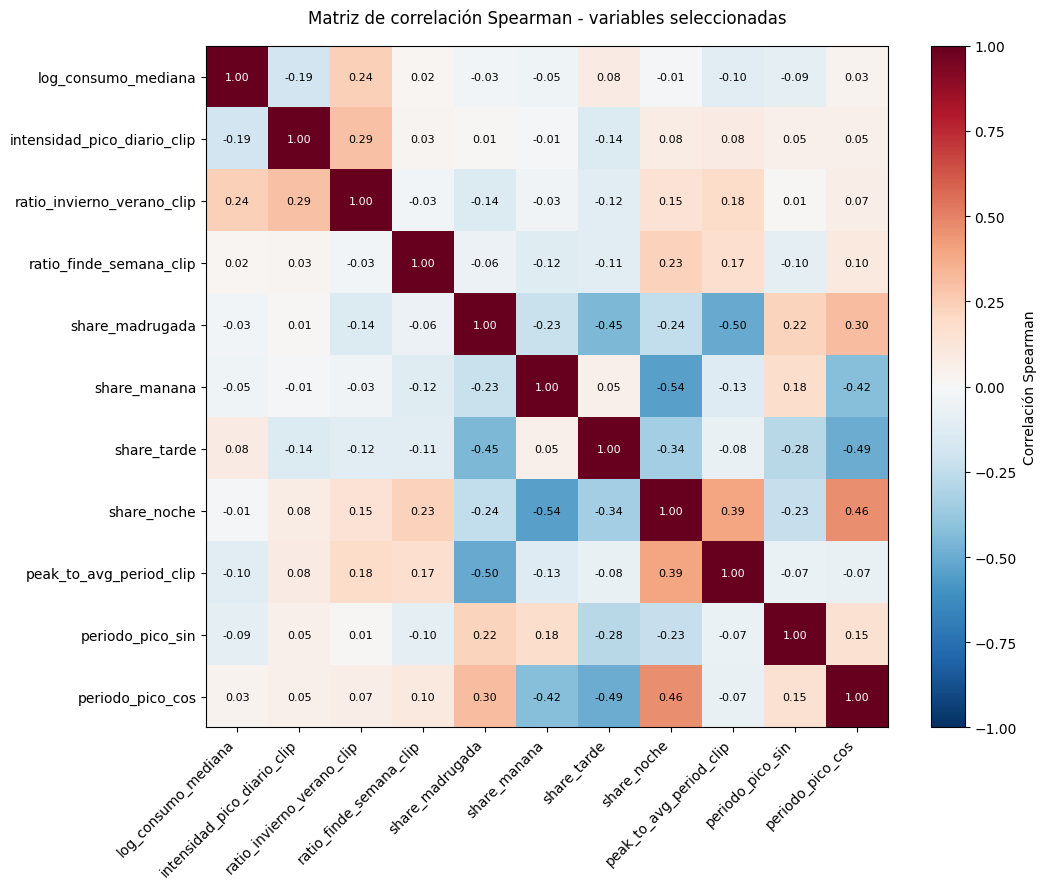

In [16]:
# Usar backend no interactivo cuando la libreta se ejecuta como script de validación.
if "get_ipython" not in globals():
    import matplotlib
    matplotlib.use("Agg")

import matplotlib.pyplot as plt

IMAGES_DIR = OUTPUT_DIR / "images"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 9))
matriz_corr = df_15_correlacion_spearman.loc[VARIABLES_SELECCIONADAS_FINALES, VARIABLES_SELECCIONADAS_FINALES]

im = ax.imshow(matriz_corr, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(VARIABLES_SELECCIONADAS_FINALES)))
ax.set_yticks(np.arange(len(VARIABLES_SELECCIONADAS_FINALES)))
ax.set_xticklabels(VARIABLES_SELECCIONADAS_FINALES, rotation=45, ha="right")
ax.set_yticklabels(VARIABLES_SELECCIONADAS_FINALES)

for i in range(len(VARIABLES_SELECCIONADAS_FINALES)):
    for j in range(len(VARIABLES_SELECCIONADAS_FINALES)):
        valor = matriz_corr.iloc[i, j]
        color_texto = "white" if abs(valor) >= 0.60 else "black"
        ax.text(j, i, f"{valor:.2f}", ha="center", va="center", color=color_texto, fontsize=8)

ax.set_title("Matriz de correlación Spearman - variables seleccionadas", pad=16)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Correlación Spearman")
fig.tight_layout()
fig.savefig(IMAGES_DIR / "matriz_correlacion_variables_comportamiento.png", dpi=160, bbox_inches="tight")

plt.show()


# 17. Construcción final de DF_Comportamiento_cluster

En esta sección se genera el DataFrame final de comportamiento. Para dejarlo listo para la etapa posterior de clustering, se imputan los pocos valores faltantes con la mediana de cada variable. Esta decisión conserva el total de hogares y es razonable porque los nulos detectados son marginales y se concentran en variables derivadas estacionales.


In [17]:
df_17_nulos_pre_imputacion = pd.DataFrame({
    "variable": VARIABLES_SELECCIONADAS_FINALES,
    "nulos": [df_14_matriz_variables_seleccionadas[var].isna().sum() for var in VARIABLES_SELECCIONADAS_FINALES],
    "pct_nulos": [round(df_14_matriz_variables_seleccionadas[var].isna().mean() * 100, 4) for var in VARIABLES_SELECCIONADAS_FINALES]
})

valores_imputacion = df_14_matriz_variables_seleccionadas[VARIABLES_SELECCIONADAS_FINALES].median(numeric_only=True)

DF_Comportamiento_cluster = df_14_matriz_variables_seleccionadas[["LCLid"] + VARIABLES_SELECCIONADAS_FINALES].copy()
DF_Comportamiento_cluster[VARIABLES_SELECCIONADAS_FINALES] = (
    DF_Comportamiento_cluster[VARIABLES_SELECCIONADAS_FINALES]
    .fillna(valores_imputacion)
)

df_17_imputacion_variables = pd.DataFrame({
    "variable": valores_imputacion.index,
    "valor_imputacion_mediana": valores_imputacion.values
})

df_17_resumen_df_comportamiento = pd.DataFrame([
    {"metrica": "hogares", "valor": DF_Comportamiento_cluster["LCLid"].nunique()},
    {"metrica": "variables_comportamiento", "valor": len(VARIABLES_SELECCIONADAS_FINALES)},
    {"metrica": "columnas_totales", "valor": DF_Comportamiento_cluster.shape[1]},
    {"metrica": "nulos_finales", "valor": DF_Comportamiento_cluster[VARIABLES_SELECCIONADAS_FINALES].isna().sum().sum()},
    {"metrica": "filas_duplicadas_LCLid", "valor": DF_Comportamiento_cluster["LCLid"].duplicated().sum()}
])

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DF_COMPORTAMIENTO_PATH = OUTPUT_DIR / "DF_Comportamiento_cluster.csv"
DICCIONARIO_COMPORTAMIENTO_PATH = OUTPUT_DIR / "diccionario_DF_Comportamiento_cluster.csv"

DF_Comportamiento_cluster.to_csv(DF_COMPORTAMIENTO_PATH, index=False)
df_14_variables_seleccionadas.to_csv(DICCIONARIO_COMPORTAMIENTO_PATH, index=False)

display(df_17_nulos_pre_imputacion)
display(df_17_imputacion_variables)
display(df_17_resumen_df_comportamiento)
display(DF_Comportamiento_cluster.head(10))
print(f"Archivo guardado en: {DF_COMPORTAMIENTO_PATH}")
print(f"Diccionario guardado en: {DICCIONARIO_COMPORTAMIENTO_PATH}")


,variable,nulos,pct_nulos
0,log_consumo_mediana,0,0.0000
1,intensidad_pico_diario_clip,0,0.0000
2,ratio_invierno_verano_clip,9,0.1625
3,ratio_finde_semana_clip,0,0.0000
4,share_madrugada,0,0.0000
5,share_manana,0,0.0000
6,share_tarde,0,0.0000
7,share_noche,0,0.0000
8,peak_to_avg_period_clip,0,0.0000
9,periodo_pico_sin,0,0.0000


,variable,valor_imputacion_mediana
0,log_consumo_mediana,2.1882
1,intensidad_pico_diario_clip,2.4315
2,ratio_invierno_verano_clip,1.2767
3,ratio_finde_semana_clip,1.0419
4,share_madrugada,0.1403
5,share_manana,0.2356
6,share_tarde,0.2705
7,share_noche,0.3374
8,peak_to_avg_period_clip,1.8058
9,periodo_pico_sin,-0.8660


,metrica,valor
0,hogares,5537
1,variables_comportamiento,11
2,columnas_totales,12
3,nulos_finales,0
4,filas_duplicadas_LCLid,0


,LCLid,log_consumo_mediana,intensidad_pico_diario_clip,ratio_invierno_verano_clip,ratio_finde_semana_clip,share_madrugada,share_manana,share_tarde,share_noche,peak_to_avg_period_clip,periodo_pico_sin,periodo_pico_cos
0,MAC000002,2.5026,3.2545,1.4445,1.0932,0.1705,0.1982,0.2363,0.3951,2.4390,-0.8660,0.5000
1,MAC000003,2.6536,2.6676,2.2559,0.9815,0.5870,0.1982,0.1077,0.1071,4.4812,0.1305,0.9914
2,MAC000004,0.9702,4.3474,1.2069,1.0377,0.2415,0.2582,0.2505,0.2498,1.2381,0.6088,-0.7934
3,MAC000005,1.7047,3.6619,1.4916,1.0063,0.0922,0.2206,0.3064,0.3808,2.8040,-1.0000,-0.0000
4,MAC000006,1.3551,2.3299,1.2185,0.9456,0.1298,0.3162,0.2388,0.3153,1.8511,0.7934,-0.6088
5,MAC000007,2.3219,4.4202,1.2784,1.1862,0.0903,0.2770,0.2767,0.3560,2.3486,-0.9914,0.1305
6,MAC000008,2.9226,2.2530,1.3933,0.9837,0.1668,0.2482,0.2894,0.2957,1.3186,-0.9914,0.1305
7,MAC000009,2.2571,1.8129,1.3308,1.0297,0.1018,0.2907,0.3284,0.2791,2.6430,-0.1305,-0.9914
8,MAC000010,3.2833,2.4422,1.3415,1.0585,0.1067,0.2257,0.3028,0.3648,2.0655,-0.9914,0.1305
9,MAC000011,2.7359,1.8841,1.4271,1.0352,0.1475,0.2098,0.2763,0.3664,1.7546,-1.0000,-0.0000


Archivo guardado en: /Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/output/clustering_horario_originales/DF_Comportamiento_cluster.csv
Diccionario guardado en: /Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/output/clustering_horario_originales/diccionario_DF_Comportamiento_cluster.csv


# 18. Gráficas descriptivas de las variables finales

Como evidencia exploratoria final, se visualizan las distribuciones de las variables incluidas en `DF_Comportamiento_cluster`. Estas gráficas permiten identificar asimetrías, rangos y concentración de valores antes de escalar o entrenar modelos en otra libreta.


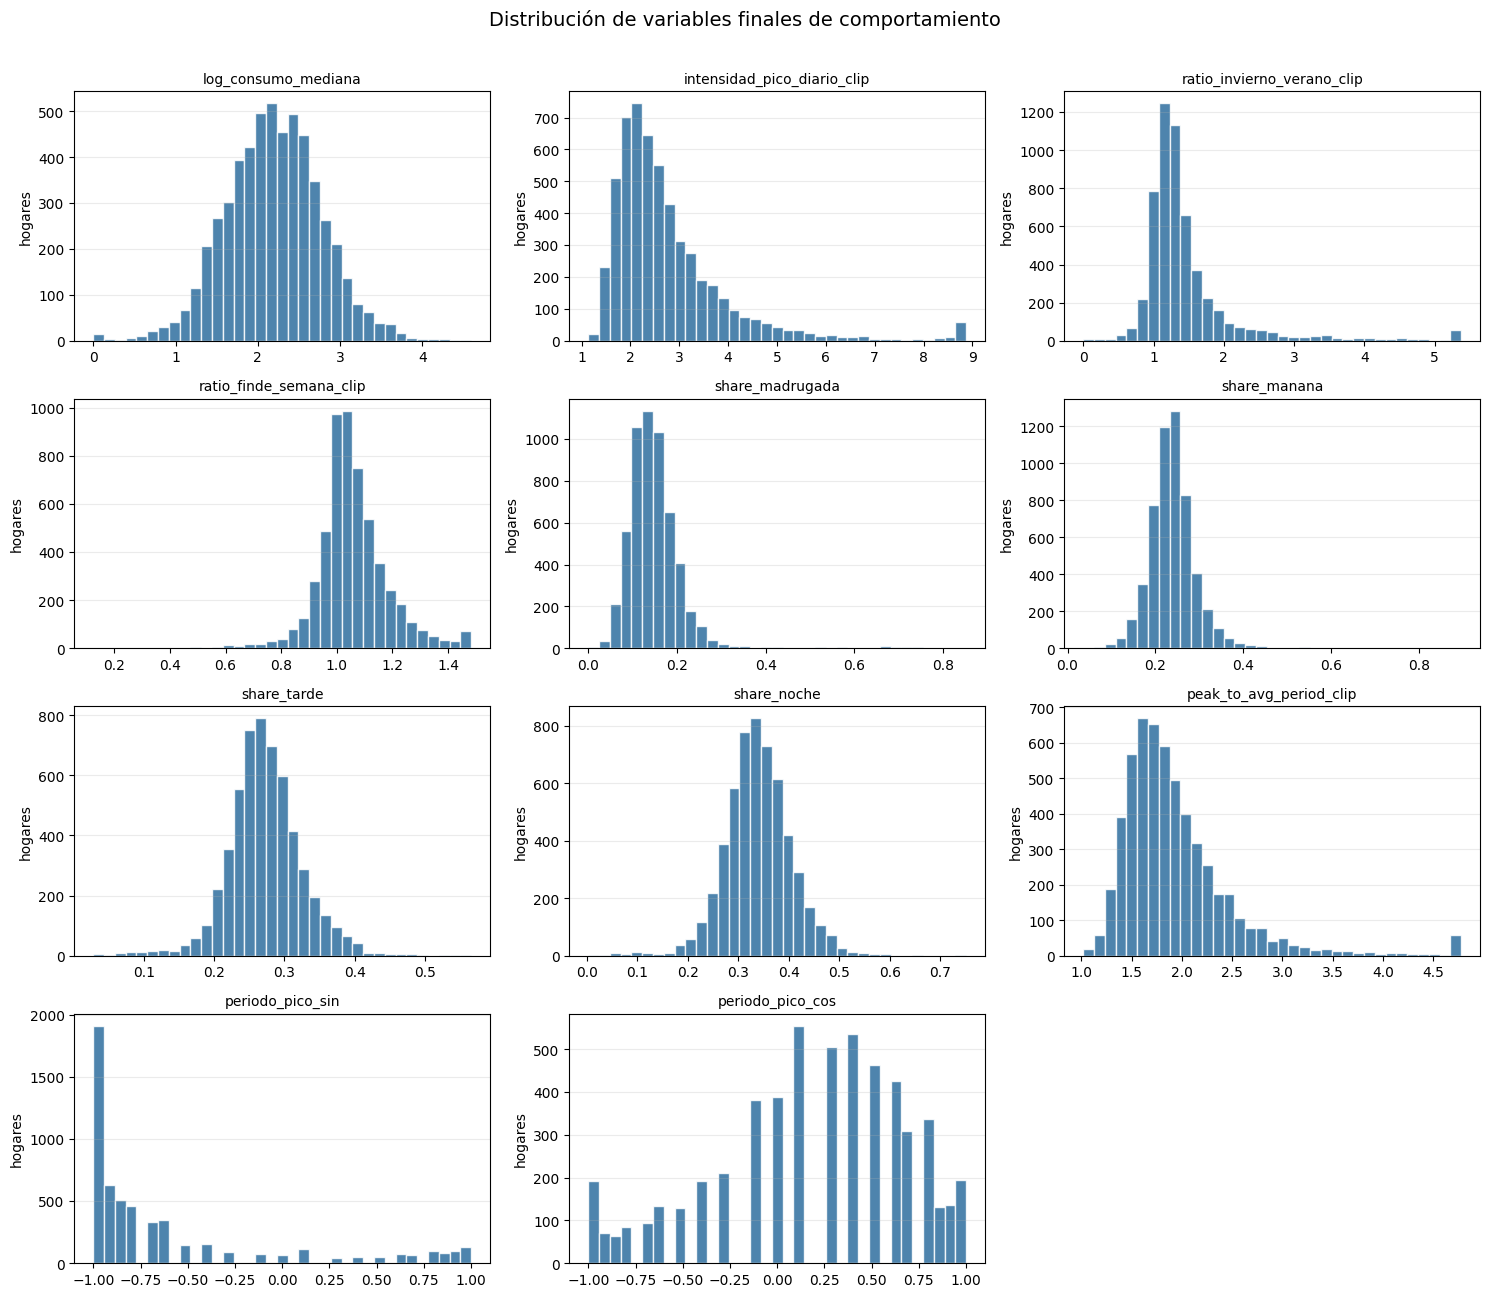

In [18]:
n_vars = len(VARIABLES_SELECCIONADAS_FINALES)
n_cols = 3
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3.2 * n_rows))
axes = axes.flatten()

for ax, variable in zip(axes, VARIABLES_SELECCIONADAS_FINALES):
    ax.hist(DF_Comportamiento_cluster[variable], bins=35, color="#2F6F9F", alpha=0.85, edgecolor="white")
    ax.set_title(variable, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("hogares")
    ax.grid(axis="y", alpha=0.25)

for ax in axes[n_vars:]:
    ax.axis("off")

fig.suptitle("Distribución de variables finales de comportamiento", fontsize=14, y=1.01)
fig.tight_layout()
fig.savefig(IMAGES_DIR / "distribuciones_DF_Comportamiento_cluster.png", dpi=160, bbox_inches="tight")
plt.show()


# 19. Conclusión de la libreta

La libreta construye una matriz final de comportamiento para hogares con medidores inteligentes, orientada a una etapa posterior de segmentación. El DataFrame final conserva variables interpretables para negocio: magnitud típica de consumo, intensidad de picos, sensibilidad estacional, diferencia fin de semana versus días laborales, distribución horaria del consumo y codificación cíclica del horario pico.

El archivo `DF_Comportamiento_cluster.csv` queda guardado en la carpeta de salida y puede utilizarse como insumo para probar algoritmos de clustering en una siguiente libreta. Las variables categóricas, como `Acorn_grouped` y `stdorToU`, deben mantenerse fuera del entrenamiento principal y utilizarse posteriormente para interpretar y validar si los segmentos resultantes tienen sentido comercial.

Desde la perspectiva del proyecto final, esta libreta cubre la preparación de datos, análisis exploratorio y selección justificada de variables. La siguiente etapa deberá abordar modelado, evaluación comparativa e interpretación ejecutiva de segmentos para responder qué decisión tomaría un cliente con base en los resultados.


## Siguiente paso del proyecto

Con `DF_Comportamiento_cluster` construido y guardado, la siguiente libreta puede enfocarse en modelado no supervisado: escalamiento, comparación de algoritmos de clustering, evaluación de métricas, selección del modelo y traducción de segmentos a campañas o promociones accionables.
